
# Overview: Hybrid Bayesian Optimization Strategy
Purpose:
This notebook demonstrates a hybrid approach for black-box optimization using Bayesian methods.
Key components:

Gaussian Process surrogate modeling
Acquisition functions (Expected Improvement, Upper Confidence Bound)
Hybrid candidate generation (global sampling + trust region + targeted perturbations)
Optional SVM filtering and ARD-based feature screening
Visualization tools for diagnostics

### Directions for Use:
1. **Run the setup cells** to load functions for GP fitting, acquisition functions, perturbations, and visualisations etc.
2. **Provide your observed data** (`X`, `Y`) from previous rounds.
3. **Fit the GP model** and compute acquisition scores.
4. **Visualise results** to guide your next round of submissions.
5. **Generate candidate queries** using the hybrid strategy.


In [28]:

import numpy as np
import pandas as pd
from typing import Optional, Tuple, Union, List, Dict
from dataclasses import dataclass, field
from pathlib import Path

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.decomposition import PCA

from sklearn.exceptions import ConvergenceWarning
import warnings
from scipy.stats import norm, qmc

import math
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


# Low-discrepancy sequence for better global coverage
try:
    from scipy.stats import qmc
    HAVE_QMC = True
except Exception:
    HAVE_QMC = False


# Suppress only ConvergenceWarning from sklearn (safe and targeted)
warnings.filterwarnings("ignore", category=ConvergenceWarning)


## Configuration Parameters
Explain the role of BOConfig:

Acquisition knobs (xi, kappa)
Candidate generation settings (n_global_factor, trust_radius_base)
GP fitting options (nu, standardize_y)
SVM and ARD toggles
Perturbation controls (use_perturbations, perturb_rate_base)

In [29]:

# Config dataclass (tweak here)
# ----------------------------
@dataclass
class BOConfig:
    # Acquisition knobs
    xi: float = 0.01             # EI exploration parameter
    kappa: float = 2.0           # UCB kappa

    # Candidate generators
    n_global_factor: int = 3000  # n_global = n_global_factor * min(D, 8)
    n_trust_base: int = 24       # n_trust = n_trust_base + 8 * min(D, 8)
    trust_radius_base: float = 0.02  # trust_radius = base / sqrt(D)

    # GP fitting
    nu: float = 2.5
    standardize_y: bool = True
    n_restarts_min: int = 30
    n_restarts_max: int = 60

    # SVM layer (toggle)
    use_svm: bool = True
    svm_kernel: str = "rbf"      # 'rbf' (recommended), 'linear', 'poly'
    svm_C: float = 1.0
    svm_gamma: str = "scale"
    svm_high_quantile: float = 0.70  # top 30% labelled HIGH by default
    svm_keep_frac: float = 0.50      # keep at least 50% of candidates after SVM filter

    # Feature screening
    use_feature_screen: bool = True
    ard_rel_threshold: float = 0.15  # drop dims with relative sensitivity below threshold

    # Scalability
    max_fit_points: int = 2000  # cap for GP fit (subsample if larger)
    random_state: int = 0
    batch_predict_size: int   = 10000   # NEW: chunk size for surrogate.predict to avoid memory spikes

    # Perturbations   
    use_perturbations: bool = True
    perturb_rate_base: float = 0.05   # used in max(0.02, perturb_rate_base / sqrt(D))

    # Dynamic exploration scheduler
    improved_last_round: bool = True

    # Neural Network
    use_nn: bool = False  # Enable neural network surrogate
    nn_hidden_layers: list = field(default_factory=lambda: [128, 128])  # <-- FIXED
    nn_activation: str = "relu"
    nn_learning_rate: float = 1e-3
    nn_weight_decay: float = 1e-4
    nn_epochs: int = 150
    nn_ensemble: int = 4
    nn_batch_size: Union[int, str] = "auto"

    # fit the surrogate in the PCA space
    use_pca: bool = False
    pca_var_keep: float = 0.9

    # Scalability / sampling
    max_candidates: int = 10000           # NEW: hard cap on total candidates
    sample_strategy: str = "sobol"        # NEW: "sobol" (default) or "lhs
    
    # --- NEW: optional hard bounds per dimension (0-based) ---
    hard_bounds: Dict[int, Tuple[float, float]] = field(default_factory=dict)




## Core Functions

### Gaussian Process Model

- fit_gp(X, Y, cfg): Fits GP with ARD Matern kernel and noise term.

In [30]:
# --- Core Functions: Neural Network Surrogate (ensemble for uncertainty) ---
class NNSurrogate:
    """
    GP-like wrapper around a BaggingRegressor(MLPRegressor) to provide:
      - predict(X, return_std=True): returns (mean, std) over ensemble
      - X_train_, y_train_: stored to mirror GP attributes used elsewhere
    If cfg.standardize_y=True, predictions are on the *standardised training scale*
    (consistent with your GP path), i.e., EI/UCB operate on the same scale as y_train_.
    """

    def __init__(self,
                 bagger: BaggingRegressor,
                 x_scaler: StandardScaler,
                 y_scaler: Optional[StandardScaler],
                 standardize_y: bool,
                 X_train: np.ndarray,
                 Y_train: np.ndarray):
        self.model = bagger
        self.x_scaler = x_scaler
        self.y_scaler = y_scaler
        self._std_eps = 1e-9  # numerical floor on std
        # Expose GP-like attributes for downstream code
        self.X_train_ = np.asarray(X_train)
        # y_train_ should be on the same scale the model was trained on
        self.y_train_ = np.asarray(Y_train)
        self._standardize_y = bool(standardize_y)

    def predict(self, X: np.ndarray, return_std: bool = False) -> Tuple[np.ndarray, Optional[np.ndarray]]:
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        # Scale inputs
        Xs = self.x_scaler.transform(X)

        # Aggregate per-estimator predictions to get mean and std
        # BaggingRegressor stores fitted base estimators in .estimators_
        preds = []
        for est in getattr(self.model, "estimators_", []):
            y_hat = est.predict(Xs)
            preds.append(y_hat)

        if len(preds) == 0:
            # Fallback to aggregated model prediction if estimators_ unavailable
            mean = self.model.predict(Xs)
            std = np.full_like(mean, fill_value=self._std_eps, dtype=float)
        else:
            P = np.stack(preds, axis=0)  # shape: (n_estimators, n_samples)
            mean = P.mean(axis=0)
            std = P.std(axis=0)
            std = np.maximum(std, self._std_eps)

        # If y was standardised during training, keep predictions on that scale
        # to remain compatible with EI/UCB which consume y_train_ in the same scale.
        # If you ever need raw-scale values, inverse-transform `mean` and recompute std.
        if return_std:
            return mean, std
        return mean


def fit_nn(X: np.ndarray, Y: np.ndarray, cfg) -> NNSurrogate:
    """
    Fit a neural-network surrogate with ensemble-based uncertainty.

    Expected cfg attributes (with safe defaults if missing):
      - nn_hidden_layers: list[int]         (default [128, 128])
      - nn_activation: str                  (default "relu")  # {"identity","logistic","tanh","relu"}
      - nn_learning_rate: float             (default 1e-3)
      - nn_weight_decay: float              (default 1e-4)    # maps to MLPRegressor 'alpha' (L2)
      - nn_batch_size: int or 'auto'        (default 'auto')
      - nn_epochs: int                      (default 300)
      - nn_ensemble: int                    (default 8)       # number of bagged models
      - random_state: int                   (default 0)
      - standardize_y: bool                 (already present in your BOConfig; default True)

    Returns:
      - NNSurrogate: object with predict(..., return_std=True),
                     and attributes X_train_, y_train_ mirroring GP.
    """
    # Ensure 2D X
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    # Pull hyperparameters from cfg with safe defaults
    hidden_layers     = tuple(getattr(cfg, "nn_hidden_layers", [128, 128]))
    activation        = getattr(cfg, "nn_activation", "relu")
    lr                = float(getattr(cfg, "nn_learning_rate", 1e-3))
    weight_decay      = float(getattr(cfg, "nn_weight_decay", 1e-4))  # scikit 'alpha'
    batch_size        = getattr(cfg, "nn_batch_size", "auto")
    epochs            = int(getattr(cfg, "nn_epochs", 150))
    n_estimators      = int(getattr(cfg, "nn_ensemble", 4))
    random_state      = int(getattr(cfg, "random_state", 0))
    standardize_y     = bool(getattr(cfg, "standardize_y", True))

    # Scale X (recommended for MLP)
    x_scaler = StandardScaler(with_mean=True, with_std=True)
    Xs = x_scaler.fit_transform(X)

    # Optionally standardise Y to mirror GP path (so EI/UCB are on training scale)
    if standardize_y:
        y_scaler = StandardScaler(with_mean=True, with_std=True)
        Ys = y_scaler.fit_transform(Y.reshape(-1, 1)).ravel()
    else:
        y_scaler = None
        Ys = Y

    # Base MLP regressor
    base_mlp = MLPRegressor(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        solver="adam",
        learning_rate_init=lr,
        alpha=weight_decay,            # L2 regularisation
        batch_size=batch_size,
        max_iter=epochs,
        early_stopping=True,           # helps stability/generalisation
        n_iter_no_change=25,
        tol=1e-4,
        validation_fraction=0.15,
        random_state=random_state,
        verbose=False
    )

    # Bagging ensemble for uncertainty; bootstrap=True gives diversity
    bagger = BaggingRegressor(
        estimator=base_mlp,
        n_estimators=n_estimators,
        bootstrap=True,
        oob_score=False,
        n_jobs=-1,
        random_state=random_state
    )

    # Fit ensemble on scaled inputs and (optionally) scaled targets
    bagger.fit(Xs, Ys)

    # Wrap in GP-like surrogate
    nn_surrogate = NNSurrogate(
        bagger=bagger,
        x_scaler=x_scaler,
        y_scaler=y_scaler,
        standardize_y=standardize_y,
        X_train=X,    # keep raw X for best-point tracking
        Y_train=Ys    # store Y on the training scale (matches predict output)
    )

    return nn_surrogate


def fit_gp(
    X: np.ndarray,
    Y: np.ndarray,
    cfg: BOConfig,
) -> GaussianProcessRegressor:
    """Fit ARD Matern(ν=cfg.nu) + White GP with dimension-aware bounds; standardise Y if requested.""" 

    if X.ndim == 1:
        X = X.reshape(-1, 1)
    n, D = int(X.shape[0]), int(X.shape[1])

    
    # Optionally subsample for scalability
    if n > cfg.max_fit_points:
        rng = np.random.default_rng(cfg.random_state)
        idx = rng.choice(n, size=cfg.max_fit_points, replace=False)
        X_fit = X[idx]
        Y_fit_raw = Y[idx]
    else:
        X_fit = X
        Y_fit_raw = Y

    # Standardise Y (safer kernel bounds)
    if cfg.standardize_y:
        scaler = StandardScaler(with_mean=True, with_std=True)
        Y_fit = scaler.fit_transform(Y_fit_raw.reshape(-1, 1)).ravel()
        normalize_y = False
    else:
        Y_fit = Y_fit_raw
        normalize_y = True


    # Per-dimension spread and geometric mean (more robust in heterogeneous D)
    s_per_dim = np.std(X_fit, axis=0) + 1e-12
    gm_s = float(np.exp(np.mean(np.log(s_per_dim))))
    length_scale_lower = 0.25 * gm_s / max(np.sqrt(D), 1.0)
    length_scale_upper = min(30.0, 6.0 * gm_s * max(np.sqrt(D), 1.0))        

    # Heuristic ARD init
    c_init = 1.0   # neutral; tune to 0.5–1.5 if needed
    ls0 = c_init * (np.std(X_fit, axis=0) + 1e-12)
    amp_bounds = (1e-6, 1e3) if cfg.standardize_y else (1e-6, 1e4)
    kernel = ConstantKernel(1.0, amp_bounds) * Matern(length_scale=ls0, 
                                                      length_scale_bounds=(max(1e-3,length_scale_lower),
                                                      float(length_scale_upper)),
                                                      nu=cfg.nu) \
                                                      + WhiteKernel(noise_level=1e-4, 
                                                        noise_level_bounds=(1e-12 if cfg.standardize_y else 1e-14,
                                                        0.75 if cfg.standardize_y else max(1e-3, 0.5 * float(np.std(Y_fit_raw)))))
    # Restarts scaled by D & n                                                                                                  
    n_restarts = int(20 + 5 * min(D, 8) + 5 * np.log10(max(n, 10)))
    n_restarts = min(max(n_restarts, cfg.n_restarts_min), cfg.n_restarts_max)
    
    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=normalize_y,
        n_restarts_optimizer=n_restarts,
        random_state=cfg.random_state)
    gp.fit(X_fit, Y_fit)
    return gp
    
  


In [31]:

# --- Hyperparameter space encoding (Functions 7/8; tune LR & L2 + architecture) ---
# hp vector in [0,1]^d; we keep d small and focused (reflecting your reflection outcomes)
# Example: d = 4 -> [lr, weight_decay, width, depth]
#  - lr           : log-uniform in [1e-5, 1e-2]
#  - weight_decay : log-uniform in [1e-6, 1e-3]
#  - width        : integer in {64, 96, 128, 160, 192, 256}
#  - depth        : integer in {1, 2, 3}

def _hp_decode(x_hp):
    """x_hp in [0,1]^4 -> dict of nn hyperparameters"""
    lr_min, lr_max = 1e-5, 1e-2
    wd_min, wd_max = 1e-6, 1e-3
    # log-uniform scaling
    lr = np.exp(np.log(lr_min) + x_hp[0] * (np.log(lr_max) - np.log(lr_min)))
    wd = np.exp(np.log(wd_min) + x_hp[1] * (np.log(wd_max) - np.log(wd_min)))

    widths = np.array([64, 96, 128, 160, 192, 256])
    depths = np.array([1, 2, 3])
    width = int(widths[min(len(widths)-1, int(np.floor(x_hp[2] * len(widths))))])
    depth = int(depths[min(len(depths)-1, int(np.floor(x_hp[3] * len(depths))))])

    # build hidden_layer_sizes from width & depth
    hidden = tuple([width] * depth)

    return dict(learning_rate=lr,
                weight_decay=wd,
                hidden_layers=hidden)


# --- Hyperparameter objective: train NN surrogate and return a scalar score ---
def evaluate_hp_candidate(x_hp, X, Y, cfg, rng=None, pca=None):

    if not getattr(cfg, "use_nn", False):
        # In GP-only runs, hyperparameter BO is not applicable
        raise RuntimeError("evaluate_hp_candidate called while cfg.use_nn=False")

    """
    Train NN surrogate with hyperparameters from x_hp and return a scalar score.
    Score is NEGATIVE validation loss (higher is better) to match 'maximise'.
    """
    hp = _hp_decode(x_hp)
    # Patch cfg for this run (do not mutate permanently)
    cfg_local = BOConfig(**{**cfg.__dict__})  # shallow copy via kwargs
    cfg_local.nn_hidden_layers = list(hp["hidden_layers"])
    cfg_local.nn_learning_rate = float(hp["learning_rate"])
    cfg_local.nn_weight_decay = float(hp["weight_decay"])
    cfg_local.use_nn = True

    # Fit NN surrogate and compute a validation score
    nn_model = fit_nn(X, Y, cfg_local)

    # Use an internal validation via bagging OOB-like split: we can simulate with a held-out split
    # For consistency with your plotting, we evaluate uncertainty-aware score:
    # mean/std on a held-out subset from median-anchored sample grid (cheap proxy).
    rng = np.random.default_rng(0) if rng is None else rng
    idx = rng.choice(len(X), size=max(8, len(X)//5), replace=False)
    X_val = X[idx]
    mean, std = _predict_in_work_space(nn_model, X_val, cfg, pca, return_std=True)

    # Validation loss proxy: mean squared error on training-scale
    y_val = nn_model.y_train_[idx]  # note: training-scale targets
    mse = float(np.mean((mean - y_val)**2))
    # Objective to MAXIMISE: negative MSE, slightly penalise high uncertainty to prefer stable configs
    score = -mse - 0.05 * float(np.mean(std))
    return score


In [32]:

# --- Core Functions: Batched predict & acquisition helpers for scalability ---
def _predict_batched(model, Xc, batch_size=10000, return_std=True, cfg=None, pca=None):
    """
    Predict in chunks to avoid large memory spikes:
    returns mean and std arrays of shape (n_samples,)
    """
    if Xc.ndim == 1:
        Xc = Xc.reshape(-1, 1)
    n = Xc.shape[0]
    means, stds = [], []
    for i in range(0, n, batch_size):
        xb = Xc[i:i+batch_size]
        if return_std:
            m, s = _predict_in_work_space(model, xb, cfg=cfg, pca=pca, return_std=True)
            means.append(m)
            stds.append(s)
        else:
            m = _predict_in_work_space(model, xb, cfg=cfg, pca=pca, return_std=False)
            means.append(m)
    mean = np.concatenate(means, axis=0)
    if return_std:
        std = np.concatenate(stds, axis=0)
        return mean, std
    return mean

def expected_improvement_batched(Xc, model, Y_best, xi=0.01, eps=1e-9, batch_size=10000):
    mean, std = _predict_batched(model, Xc, batch_size=batch_size, return_std=True)
    std = np.maximum(std, eps)
    imp = mean - Y_best - xi
    Z = imp / std
    ei = imp * norm.cdf(Z) + std * norm.pdf(Z)
    ei[std <= eps] = np.maximum(0.0, imp[std <= eps])
    return ei

def upper_confidence_bound_batched(Xc, model, kappa=2.0, batch_size=10000):
    mean, std = _predict_batched(model, Xc, batch_size=batch_size, return_std=True)
    return mean + kappa * std


# --- Acquisition computed from a single predict call ---
def acquisition_scores_single_pass(
    model, Xc_work, Y_best, xi=0.01, kappa=2.0, eps=1e-9
):
    # One predict call
    mean, std = model.predict(Xc_work, return_std=True)
    std = np.maximum(std, eps)

    imp = mean - Y_best - xi
    Z = imp / std
    ei = imp * norm.cdf(Z) + std * norm.pdf(Z)
    ei[std <= eps] = np.maximum(0.0, imp[std <= eps])

    ucb = mean + kappa * std
    return ei, ucb, mean, std


def acquisition_scores_batched_single_pass(
    model, Xc_work, Y_best, xi=0.01, kappa=2.0, eps=1e-9, batch_size=20000
):
    n = Xc_work.shape[0]
    ei_list, ucb_list = [], []
    for i in range(0, n, batch_size):
        xb = Xc_work[i:i+batch_size]
        # single predict call
        mean, std = model.predict(xb, return_std=True)
        std = np.maximum(std, eps)
        imp = mean - Y_best - xi
        Z = imp / std
        ei = imp * norm.cdf(Z) + std * norm.pdf(Z)
        ei[std <= eps] = np.maximum(0.0, imp[std <= eps])
        ucb = mean + kappa * std
        ei_list.append(ei)
        ucb_list.append(ucb)

    return np.concatenate(ei_list), np.concatenate(ucb_list)



In [33]:

# --- Core Functions: PCA helper (optional) ---
def fit_pca_transform(X, var_keep: float=0.95):
    """Fit PCA on X and return (pca, Z) where Z = PCA(X)."""
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    pca = PCA(n_components=var_keep, svd_solver='full', random_state=0)
    Z = pca.fit_transform(X)
    return pca, Z



def pca_transform_candidates(pca: PCA, Xc: np.ndarray) -> np.ndarray:
    """Transform candidate points Xc to PCA space (Zc = PCA(Xc))."""
    if Xc.ndim == 1:
        Xc = Xc.reshape(-1, 1)
    return pca.transform(Xc)



#Use the raw X for medians and axes, but call surrogate.predict on the *working space*.
# A simple way is to add a small wrapper predict function:

def _predict_in_work_space(model, X_points, cfg, pca=None, return_std=True):
    if X_points.ndim == 1:
        X_points = X_points.reshape(-1, 1)
    use_pca = bool(getattr(cfg, "use_pca", False))
    if use_pca and pca is not None:
        Z_points = pca_transform_candidates(pca, X_points)
        return model.predict(Z_points, return_std=return_std)
    return model.predict(X_points, return_std=return_std)


In [34]:

# --- Hyperparameter BO Persistence helpers ---
import json
import csv
from datetime import datetime

def load_hp_checkpoint(function_path: Path):
    """
    Load best NN hyperparameter checkpoint if present.
    Returns dict or None.
    """
    p = Path(function_path) / "hp_best.json"
    if p.exists():
        with open(p, "r") as f:
            try:
                return json.load(f)
            except Exception:
                return None
    return None

def save_hp_checkpoint(function_path: Path,
                       best_hp_decoded: dict,
                       best_score: float,
                       hp_X: np.ndarray,
                       hp_Y: np.ndarray,
                       cfg):
    """
    Persist best hyperparameters and score to JSON and append a row to CSV log.
    """
    meta = {
        "timestamp": datetime.utcnow().isoformat() + "Z",
        "best_score": float(best_score),
        "best_hp_decoded": {
            "hidden_layers": list(best_hp_decoded.get("hidden_layers", [])),
            "learning_rate": float(best_hp_decoded.get("learning_rate", 1e-3)),
            "weight_decay": float(best_hp_decoded.get("weight_decay", 1e-4)),
        },
        "hp_dataset_size": int(len(hp_Y)),
        "random_state": int(getattr(cfg, "random_state", 0)),
    }
    # JSON checkpoint
    with open(Path(function_path) / "hp_best.json", "w") as f:
        json.dump(meta, f, indent=2)

    # Append to CSV log (creates header if file is new)
    log_path = Path(function_path) / "hp_log.csv"
    write_header = not log_path.exists()
    with open(log_path, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(["timestamp",
                             "best_score",
                             "learning_rate",
                             "weight_decay",
                             "hidden_layers",
                             "hp_dataset_size",
                             "random_state"])
        writer.writerow([meta["timestamp"],
                         meta["best_score"],
                         meta["best_hp_decoded"]["learning_rate"],
                         meta["best_hp_decoded"]["weight_decay"],
                         "-".join(map(str, meta["best_hp_decoded"]["hidden_layers"])),
                         meta["hp_dataset_size"],
                         meta["random_state"]])


### Acquisition Functions

- expected_improvement(...)
- upper_confidence_bound(...)


In [35]:
# ----------------------------
# Acquisition functions (EI/UCB)
# ----------------------------

def expected_improvement(Xc, gp, Y_best, xi=0.01, eps=1e-9):
    """ Numerically stable EI (protect against std→0) """
    mean, std = gp.predict(Xc, return_std=True)
    std = np.maximum(std, eps)
    imp = mean - Y_best - xi
    Z = imp / std
    ei = imp * norm.cdf(Z) + std * norm.pdf(Z)
    # For std≈0: EI should be ~max(0, imp)
    ei[std <= eps] = np.maximum(0.0, imp[std <= eps])
    return ei


def upper_confidence_bound(Xc, gp, kappa=2.0):
    mean, std = gp.predict(Xc, return_std=True)
    return mean + kappa * std


### 3.3 Feature Screening & SVM

- screen_dimensions_by_ard(...)
- train_svm_classifier(...)

In [36]:

# ----------------------------
# Feature screening (ARD)
# ----------------------------
def screen_dimensions_by_ard(gp: GaussianProcessRegressor, threshold: float = 0.15) -> Optional[np.ndarray]:  
    """Return boolean mask of kept dimensions using ARD sensitivities (1/length-scale)."""
    try:
        matern = gp.kernel_.k1.k2
        ls = np.asarray(matern.length_scale, dtype=float)
        sens = 1.0 / (ls + 1e-12)
        rel = sens / (np.max(sens) + 1e-12)
        keep = rel >= threshold
        return keep if np.sum(keep) >= 1 else None
    except Exception:
        return None


def train_svm_classifier(X: np.ndarray, Y: np.ndarray, cfg: BOConfig) -> Optional[SVC]:
    """Soft-margin kernel SVM to label HIGH vs LOW performance."""
    if not cfg.use_svm:
        return None
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    q = np.quantile(Y, cfg.svm_high_quantile)
    y_cls = (Y >= q).astype(int)
    if y_cls.sum() < 2 or (len(y_cls) - y_cls.sum()) < 2 or len(y_cls) < 12:
        return None
    svm = SVC(C=cfg.svm_C, kernel=cfg.svm_kernel, gamma=cfg.svm_gamma,
              probability=False, random_state=cfg.random_state)
    svm.fit(X, y_cls)
    return svm


### Candidate Generation

- _lhs(...): Latin Hypercube Sampling
- _format_for_portal(...): Portal formatting
- generate_perturbations(...): Local refinement


In [37]:
# ----------------------------
# Portal formatting (six dp)
# ----------------------------
def _format_for_portal(x: np.ndarray) -> str:
    """Clip to [0, 0.999999] and format as hyphen-separated 6 dp (portal requirement)."""
    x = np.clip(np.asarray(x, float), 0.0, 1.0 - 1e-6)
    return "-".join(f"{v:.6f}" for v in x)  # matches your Week-3 formatting


# ----------------------------
# Utility: LHS in [0,1]^d
# ----------------------------
def _lhs(n: int, d: int, rng: np.random.Generator) -> np.ndarray:
    """Simple Latin Hypercube Sampling in [0,1]^d."""
    cut = np.linspace(0, 1, n + 1)
    a, b = cut[:-1], cut[1:]
    X = rng.uniform(a, b, size=(d, n)).T  # shape (n, d)
    for j in range(d):
        rng.shuffle(X[:, j])
    return X

def generate_perturbations(top_points, perturbation_rate=0.05, bounds=(0, 1), rng=None):
    rng = np.random.default_rng(0) if rng is None else rng
    perturbed_points = []
    for point in top_points:
        delta = rng.uniform(-perturbation_rate, perturbation_rate, size=point.shape)
        p = np.clip(point + delta, bounds[0], bounds[1])
        perturbed_points.append(p)
    return np.array(perturbed_points)


def _sobol(n: int, d: int, rng=None) -> np.ndarray:
    """
    Sobol low-discrepancy samples in [0,1]^d with balance-friendly count.
    Generates 2^m points via random_base2 and slices to n to avoid warnings
    and retain balance properties.

    Parameters
    ----------
    n : int
        Number of points requested (any positive integer).
    d : int
        Dimension of the space.
    rng : np.random.Generator or None
        Optional RNG to derive a deterministic seed.

    Returns
    -------
    np.ndarray
        Array of shape (n, d), dtype float64 by default (use .astype(np.float32)
        at call sites if you want smaller memory footprint).
    """
    # Fallback to LHS if QMC isn't available
    if not HAVE_QMC:
        return _lhs(n, d, rng)

    # Derive a deterministic seed from rng if provided
    seed = None
    if rng is not None and hasattr(rng, "bit_generator"):
        try:
            seed = rng.bit_generator._seed_seq.entropy
        except Exception:
            seed = None

    engine = qmc.Sobol(d=d, scramble=True, seed=seed)

    # Find m s.t. 2^m >= n (ensure at least 2 points)
    m = max(1, int(math.ceil(math.log2(max(2, n)))))

    # Generate exactly 2^m points; this avoids the balance warning
    X = engine.random_base2(m=m)  # shape: (2**m, d)

    # Slice down to n points and return (np.ndarray)
    return X[:n]



def svm_gate_fast(scores: np.ndarray, keep_frac: float) -> np.ndarray:
    """
    Return indices of items whose score is >= the (1 - keep_frac) quantile,
    computed via np.partition (O(n)) instead of a full sort (O(n log n)).
    """
    n = len(scores)
    if n == 0 or keep_frac <= 0.0:
        # keep everything if keep_frac is 0 (or scores empty)
        return np.arange(n)
    if keep_frac >= 1.0:
        # keep only the top quantile (i.e., threshold near min)
        return np.arange(n)

    # kth index for the (1 - keep_frac) quantile (0-based)
    # Example: keep_frac=0.40 -> quantile q=0.60 -> k = ceil(n*0.60) - 1
    q = 1.0 - float(keep_frac)
    k = int(np.ceil(n * q)) - 1
    k = np.clip(k, 0, n - 1)

    # Partition to find threshold in O(n)
    thr = np.partition(scores, k)[k]
    return np.where(scores >= thr)[0]


def evaluate_hp_candidate_fast(x_hp, X, Y, cfg, pca=None):
    """
    Lightweight HP evaluation: trains NN surrogate with minimal cost.
    - Uses 1 estimator (no bagging)
    - Fewer epochs
    - Same scoring logic (negative MSE + uncertainty penalty)
    """
    hp = _hp_decode(x_hp)
    cfg_fast = BOConfig(**{**cfg.__dict__})  # shallow copy
    cfg_fast.nn_hidden_layers = list(hp["hidden_layers"])
    cfg_fast.nn_learning_rate = float(hp["learning_rate"])
    cfg_fast.nn_weight_decay = float(hp["weight_decay"])
    cfg_fast.use_nn = True

    # Fast toggles
    cfg_fast.nn_ensemble = 1
    cfg_fast.nn_epochs = 60  # instead of 150
    cfg_fast.standardize_y = True

    # Fit NN quickly
    X_work = pca_transform_candidates(pca, X) if (cfg_fast.use_pca and pca is not None) else X
    nn_model = fit_nn(X_work, Y, cfg_fast)

    # Quick validation score
    rng = np.random.default_rng(cfg_fast.random_state)
    idx = rng.choice(len(X), size=max(8, len(X)//6), replace=False)
    mean, std = _predict_in_work_space(nn_model, X[idx], cfg_fast, pca, return_std=True)
    y_val = nn_model.y_train_[idx]
    mse = float(np.mean((mean - y_val)**2))
    return -mse - 0.03 * float(np.mean(std))


### Query Proposal

- propose_next_queries(...): Combines global, trust-region, and perturbation candidates; applies SVM filter and ranks by EI/UCB.

In [38]:

def rank_topk_fast(ei, ucb, k_final, buffer_mult=10):
    """
    Return indices of the top k_final candidates using a two-stage selection:
      1) argpartition to keep a buffer of the top M by EI (O(n))
      2) stable tie-break sort inside the buffer with EI -> UCB (O(M log M))
    """
    # Safety: handle tiny arrays
    n = len(ei)
    if n <= k_final:
        # If fewer candidates than k, just do a small full sort for correctness
        order = np.lexsort((-ucb, -ei))
        return order[:k_final]

    M = min(n, max(k_final * buffer_mult, k_final))
    # Stage 1: keep top-M by EI (no full sort)
    idx_buf = np.argpartition(-ei, M - 1)[:M]
    # Stage 2: sort inside the buffer using EI as primary, UCB as secondary
    order_buf = np.lexsort((-ucb[idx_buf], -ei[idx_buf]))
    return idx_buf[order_buf][:k_final]



def propose_next_queries(X: np.ndarray, Y: np.ndarray, model, cfg: BOConfig, k_final: int = 5, pca: PCA = None):
    rng = np.random.default_rng(cfg.random_state)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    n, D = int(X.shape[0]), int(X.shape[1])


    # --- Candidate counts (with hard cap) & trust radius ---
    n_global_factor = int(getattr(cfg, "n_global_factor", 2000))
    if D >= 6:
        n_global_factor = max(n_global_factor, 3000)
    
    # Desired counts
    n_global = n_global_factor * min(D, 8)
    n_trust  = cfg.n_trust_base + 8 * min(D, 8)
    m        = min(5, max(2, D // 2))  # number of top anchors
    
    # NEW: Hard cap on total candidates
    max_total = int(getattr(cfg, "max_candidates", 10000))
    # Reserve space for trust-region and perturbations (≈ 2*m)
    reserve   = n_trust + (2 * m)
    n_global  = max(1000, min(n_global, max_total - reserve))  # ensure at least 1000 global samples


    
    # Use Week-5 helper if available
    if "dim_aware_trust_radius" in globals():
        trust_radius = dim_aware_trust_radius(D, base=float(getattr(cfg, "trust_radius_base", 0.03)))
    else:
        trust_radius = float(getattr(cfg, "trust_radius_base", 0.03)) * (0.85 if D >= 6 else 1.0)
    trust_radius = max(1e-6, trust_radius)

    # --- Surrogate to use (GP or NN) ---
    surrogate = model

    # --- Current best on the surrogate training scale if present ---
    try:
        Y_train = surrogate.y_train_
        Y_best  = float(np.max(Y_train))
        X_train = surrogate.X_train_
        X_best  = X_train[int(np.argmax(Y_train))]
    except Exception:
        Y_best  = float(np.max(Y))
        X_best  = X[int(np.argmax(Y))]


    # Choose sampler based on cfg.sample_strategy (defaults to Sobol)
    if getattr(cfg, "sample_strategy", "sobol").lower() == "sobol" and HAVE_QMC:
        Xg = _sobol(n_global, D, rng=rng).astype(np.float32)
    else:
        Xg = _lhs(n_global, D, rng=rng).astype(np.float32)


    # --- Trust-region candidates around top-m points ---
    m = min(5, max(2, D // 2))
    top_idx = np.argsort(Y)[-m:]
    Xt_list = []
    for xb in X[top_idx]:
        deltas = rng.uniform(-trust_radius, trust_radius, size=(n_trust // m, D))
        Xt_list.append(np.clip(xb + deltas, 0.0, 1.0 - 1e-6))
    Xt = np.vstack(Xt_list).astype(np.float32)

    # --- ARD screening ---
    dim_mask = np.ones(D, dtype=bool)
    if getattr(cfg, "use_feature_screen", True):
        ard_mask = screen_dimensions_by_ard(surrogate, threshold=cfg.ard_rel_threshold)
        if ard_mask is not None and ard_mask.sum() >= 1 and ard_mask.sum() < D:
            dim_mask = ard_mask
            x_med = np.median(X, axis=0)
            Xg[:, ~dim_mask] = x_med[~dim_mask]
            Xt[:, ~dim_mask] = x_med[~dim_mask]

    # --- Targeted perturbations ---
    Xp = np.empty((0, D), dtype=float)
    if getattr(cfg, "use_perturbations", True):
        perturb_rate = max(0.02, cfg.perturb_rate_base / np.sqrt(D))
        Xp = generate_perturbations(X[top_idx], perturbation_rate=perturb_rate, bounds=(0.0, 1.0), rng=rng).astype(np.float32)
        if dim_mask.sum() < D:
            x_med = np.median(X, axis=0)
            Xp[:, ~dim_mask] = x_med[~dim_mask]

    # --- Combine candidate pools ---
    Xc = (np.vstack([Xg, Xt, Xp]) if len(Xp) else np.vstack([Xg, Xt])).astype(np.float32)
    Xc = apply_hard_bounds(Xc, cfg.hard_bounds)  # e.g., {1: (0.0, 0.80)}

    # ======================================================================
    # FUNCTION 1 OVERRIDE — Max–Min geometric exploration
    # ======================================================================
    if function_name == 'function_1':
        # Farthest‑point selection to break GP collapse
        numeric = pick_farthest(Xc, X, k_final)
        formatted = ["{:.6f}-{:.6f}".format(*row) for row in numeric]
        return numeric, formatted
    # ======================================================================
    
    # --- Optional SVM pre-filter (with adaptive gating per Week-5) ---
    svm = train_svm_classifier(X, Y, cfg)
    if svm is not None and len(Xc) > 0 and hasattr(svm, "decision_function"):
        scores = svm.decision_function(Xc)
        
        # Local default to prevent UnboundLocalError inside this block
        keep_idx = np.array([], dtype=int)

        # Fast gate via partition (no full sort/quantile sort path)
        q_keep = float(getattr(cfg, "svm_keep_frac", 0.5))
        keep_idx = svm_gate_fast(scores, keep_frac=q_keep)

        # Adaptive relax if buffer collapses (same rule you had)
        min_keep = max(k_final * 10, int(0.25 * len(Xc)))
        if keep_idx.size < min_keep:
            q_relaxed = max(0.35, q_keep - 0.15)
            keep_idx = svm_gate_fast(scores, keep_frac=q_relaxed)

        # Apply the gate (only if something survived)
        if keep_idx.size > 0:
            Xc = Xc[keep_idx]
    # else: no SVM or no decision_function ⇒ do not gate; keep Xc as-i

    
    # --- ENSURE AT LEAST ONE GLOBAL CANDIDATE SURVIVES ---
    Xc = ensure_global_floor(Xc, Xg_pool=Xg, min_global=1)


    # --- Transform candidates to working space (PCA optional) ---
    Xc_work = pca_transform_candidates(pca, Xc).astype(np.float32) if getattr(cfg, "use_pca", False) and pca is not None else Xc

   
    # --- Batch size for acquisition (ensure it's not too small) --
    batch_size = max(10000, cfg.batch_predict_size)
    

    # --- Single-pass batched acquisition: one predict for both EI and UCB ---
    Y_best = float(np.max(getattr(surrogate, "y_train_", Y)))
    ei, ucb = acquisition_scores_batched_single_pass(
        surrogate, Xc_work, Y_best, xi=cfg.xi, kappa=cfg.kappa, batch_size=batch_size
    )



    # --- Rank candidates (Top‑K without sorting everything) ---
    top_idx = rank_topk_fast(ei, ucb, k_final=k_final, buffer_mult=10)
    log_topk_diversity(top_idx)
    topK = Xc[top_idx]                 # shape (k_final, D)
    
    # ============================================================
    # (7) GEOMETRIC INSURANCE POINT (GLOBAL FAR-POINT CANDIDATE)
    # ============================================================
    # We select ONE farthest point relative to X (the dataset), taken from the
    # GLOBAL candidate pool (Xg). This ensures exploration even if BO collapses.
    
    # Only build farthest-point candidate if Xg exists and has enough points
    if Xg is not None and len(Xg) > 0:
        X_farthest = pick_farthest(Xg, X, k=1)     # shape (1, D)
    else:
        X_farthest = None
    
    # ============================================================
    # (Strict mode for Function 4)
    # ALWAYS ensure at least one global or geometric far-point survives
    # ============================================================
    
    if function_name == 'function_4':
        # Build a base pool: top‑K PLUS the geometric insurance point
        if X_farthest is not None:
            merged = np.vstack([topK, X_farthest])
        else:
            merged = topK.copy()
    
        # Apply global-floor guarantee
        Xc_final = ensure_global_floor(
            merged,
            Xg_pool=Xg,          # pass original global candidate pool
            min_global=1
        )
    
    else:
        # Standard behaviour for other functions
        if X_farthest is not None:
            merged = np.vstack([topK, X_farthest])
        else:
            merged = topK.copy()
    
        try:
            # Apply global-floor guarantee (helpful, not enforced)
            Xc_final = ensure_global_floor(
                merged,
                Xg_pool=Xg,
                min_global=1
            )
        except NameError:
            Xc_final = merged


    # --- Deduplicate & format only the (k_final [+1]) points ---
    seen, numeric, formatted = set(), [], []
    for x in Xc_final:
        fx = _format_for_portal(x)
        if fx not in seen:
            seen.add(fx)
            numeric.append(x)
            formatted.append(fx)
        if len(numeric) >= k_final:
            break
    
    return numeric, formatted




### Visualization Utilities

- plot_2d_ei_slice(...): EI + GP mean contour (optional)
- plot_acquisition_functions(...): EI/UCB overlays
- plot_gp_slice(...): 1D/2D GP slices
- pairplot_ei(...): Multi-pair EI diagnostics
- plot_ridge_scan(...): EI/mean scans for ridge-defining pairs

In [39]:
# --- Plotting: 2D EI contour slices (optional) ---

# --- FIX: PCA-aware 2D EI slice helper (complete, self-contained) ---

def plot_2d_ei_slice(X, Y, model, cfg, pca, d1, d2, n_points=100, Y_best=None):
    """Vary two dims (d1, d2); fix others at median. Show posterior mean & EI; mark EI slice maximum."""
    if Y_best is None:
        Y_best = float(np.max(getattr(model, "y_train_", Y)))

    fixed = np.median(X, axis=0)
    g1 = np.linspace(0, 1, n_points)
    g2 = np.linspace(0, 1, n_points)
    G1, G2 = np.meshgrid(g1, g2)

    # Raw-space grid
    X_full = np.tile(fixed, (n_points * n_points, 1))
    X_full[:, d1] = G1.ravel()
    X_full[:, d2] = G2.ravel()

    # PCA-aware prediction
    mean, std = _predict_in_work_space(model, X_full, cfg, pca, return_std=True)

    # EI in the same working space
    X_work = pca_transform_candidates(pca, X_full) if getattr(cfg, "use_pca", False) and pca is not None else X_full
    ei = expected_improvement(X_work, model, Y_best=Y_best)

    mean_2d = mean.reshape(n_points, n_points)
    ei_2d   = ei.reshape(n_points, n_points)

    # EI max
    max_idx = np.unravel_index(np.argmax(ei_2d), ei_2d.shape)
    max_x1 = g1[max_idx[1]]
    max_x2 = g2[max_idx[0]]

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    c0 = ax[0].contourf(G1, G2, mean_2d, cmap='viridis')
    fig.colorbar(c0, ax=ax[0])
    ax[0].scatter(X[:, d1], X[:, d2], color='red', s=20, label='Observed')
    ax[0].set_title(f"Posterior mean (dims {d1+1} vs {d2+1})")
    ax[0].set_xlabel(f"Dim {d1+1}")
    ax[0].set_ylabel(f"Dim {d2+1}")
    ax[0].legend(loc='upper right')

    c1 = ax[1].contourf(G1, G2, ei_2d, cmap='plasma')
    fig.colorbar(c1, ax=ax[1])
    ax[1].scatter(max_x1, max_x2, color='black', s=80, marker='*', label='EI slice max')
    ax[1].set_title(f"EI (dims {d1+1} vs {d2+1})")
    ax[1].set_xlabel(f"Dim {d1+1}")
    ax[1].set_ylabel(f"Dim {d2+1}")
    ax[1].legend(loc='upper right')
    plt.tight_layout()
    plt.show()



    
def plot_acquisition_functions(X_grid, ei_scores, ucb_scores):
    plt.figure(figsize=(10, 6))
    plt.plot(X_grid, ei_scores, label='Expected Improvement', color='green')
    plt.plot(X_grid, ucb_scores, label='Upper Confidence Bound', color='orange')
    plt.xlabel('Input')
    plt.ylabel('Acquisition Score')
    plt.title('Acquisition Functions')
    plt.legend()
    plt.show()


# NEW FUNCTION: Handles 1D and 2D slices for high-dimensional input
def plot_gp_slice(X, Y, model, cfg,pca,dims_to_vary=[0], query_point=None, beta=1.96, n_points=50):
    """
    Visualize GP predictions for high-dimensional input by varying selected dimensions
    and fixing others at their median values.
    dims_to_vary: list of dimension indices to vary (1D or 2D slice)
    """
    fixed_values = np.median(X, axis=0)

    if len(dims_to_vary) == 1:
        # 1D slice
        var_dim = dims_to_vary[0]
        X_grid = np.linspace(0, 1, n_points)
        X_full = np.tile(fixed_values, (n_points, 1))
        X_full[:, var_dim] = X_grid


        # PCA-aware prediction
        mean, std = _predict_in_work_space(model, X_full, cfg, pca, return_std=True)
        
        plt.figure(figsize=(10, 6))
        plt.scatter(X[:, var_dim], Y, color='red', label='Observed Points')
        plt.plot(X_grid, mean, color='blue', label='Posterior Mean')
        plt.fill_between(X_grid, mean - beta * std, mean + beta * std,
                         alpha=0.2, color='blue', label='95% Confidence Interval')
        
        # Highlight query point
        if query_point is not None:
            qp_mean, _ = _predict_in_work_space(model, query_point.reshape(1, -1), cfg, pca, return_std=True)
            plt.scatter(query_point[var_dim], qp_mean[0],
                        color='black', s=100, marker='*', label='Chosen Query')


        plt.xlabel(f'Dimension {var_dim+1}')
        plt.ylabel('Output')
        plt.title(f'1D Slice (Other dims fixed at median)')
        plt.legend()
        plt.show()

    elif len(dims_to_vary) == 2:
        # 2D slice
        d1, d2 = dims_to_vary
        grid1 = np.linspace(0, 1, n_points)
        grid2 = np.linspace(0, 1, n_points)
        X_full = np.tile(fixed_values, (n_points * n_points, 1))
        X_full[:, d1] = np.repeat(grid1, n_points)
        X_full[:, d2] = np.tile(grid2, n_points)

        
        mean, _ = _predict_in_work_space(model, X_full, cfg, pca, return_std=True)
        Z = mean.reshape(n_points, n_points)

        plt.figure(figsize=(8, 6))
        plt.contourf(grid1, grid2, Z, cmap='viridis')
        plt.colorbar(label='Posterior Mean')
        plt.scatter(X[:, d1], X[:, d2], color='red', label='Observed Points')

        # Highlight query point
        if query_point is not None:
            plt.scatter(query_point[d1], query_point[d2], color='black', s=100, marker='*', label='Chosen Query')

        plt.xlabel(f'Dimension {d1+1}')
        plt.ylabel(f'Dimension {d2+1}')
        plt.title(f'2D Slice (Other dims fixed at median)')
        plt.legend()
        plt.show()



def pairplot_ei(
    X: np.ndarray,
    Y: np.ndarray,
    gp,
    n_dims: int = 4,
    n_points: int = 60,
    dims: Optional[List[int]] = None,   # <-- fixed
    cmap: str = "plasma"
):
    """
    Pairplot of Expected Improvement (EI) over selected dimensions.

    - Uses constrained_layout=True (no tight_layout call) to avoid layout warnings.
    - Single shared colorbar (ScalarMappable) for all EI panels.
    """
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    n, D = X.shape
    assert D >= 2, "Pairplot requires at least 2 dimensions."

    # Y_best on GP training scale if available
    try:
        Y_best = float(np.max(gp.y_train_))
    except Exception:
        Y_best = float(np.max(Y))

    # Pick dims
    if dims is None:
        variances = np.var(X, axis=0)
        dims = list(np.argsort(variances)[-n_dims:])
    else:
        dims = list(dims)
    k = len(dims)
    if k < 2:
        raise ValueError("Need at least 2 dimensions for a pairplot.")

    fixed = np.median(X, axis=0)
    g = np.linspace(0.0, 1.0, n_points)
    G1, G2 = np.meshgrid(g, g)

    # Use constrained_layout to avoid tight_layout warning
    fig, axes = plt.subplots(k, k, figsize=(3.5*k, 3.5*k), constrained_layout=True)
    if k == 2:
        axes = np.array(axes).reshape(2, 2)

    # We'll compute global EI min/max for a shared color scale
    global_min, global_max = np.inf, -np.inf
    ei_cache = {}  # (i,j) -> 2D EI array

    # First pass: compute EI for all off-diagonal pairs and store min/max
    for i, d1 in enumerate(dims):
        for j, d2 in enumerate(dims):
            if i == j:
                continue
            X_full = np.tile(fixed, (n_points * n_points, 1))
            X_full[:, d1] = G1.ravel()
            X_full[:, d2] = G2.ravel()


            if getattr(cfg, "use_pca", False) and pca is not None:
                X_work = pca_transform_candidates(pca, X_full)
            else:
                X_work = X_full
        
            ei_vals = expected_improvement(X_work, gp, Y_best=Y_best)
            ei_2d = ei_vals.reshape(n_points, n_points)

            ei_cache[(i, j)] = ei_2d
            global_min = min(global_min, float(np.min(ei_2d)))
            global_max = max(global_max, float(np.max(ei_2d)))

    # Normalizer + mappable for shared colorbar
    norm = Normalize(vmin=global_min, vmax=global_max)
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    # Second pass: plot
    for i, d1 in enumerate(dims):
        for j, d2 in enumerate(dims):
            ax = axes[i, j]
            if i == j:
                # keep diagonal blank
                ax.axis("off")
                continue

            ei_2d = ei_cache[(i, j)]
            c = ax.contourf(G1, G2, ei_2d, levels=20, cmap=cmap, norm=norm)

            # Mark EI max
            max_idx = np.unravel_index(np.argmax(ei_2d), ei_2d.shape)
            ax.scatter(g[max_idx[1]], g[max_idx[0]], s=40, c='k', marker='*', label='EI max')

            ax.set_xlabel(f"Dim {d1+1}")
            ax.set_ylabel(f"Dim {d2+1}")
            ax.set_title(f"EI: (Dim {d1+1} vs {d2+1})")
            ax.set_xticks(np.linspace(0, 1, 5))
            ax.set_yticks(np.linspace(0, 1, 5))

    # Single shared colorbar
    cbar = fig.colorbar(sm, ax=axes, fraction=0.03, pad=0.02)
    cbar.set_label("Expected Improvement")


# --- Week-5 Visualization Enhancements ---
def plot_ridge_scan(X, Y, model, cfg, pca, dim_pair, fixed_dim, fixed_values, n_points=60):
    """
    Visualize EI and posterior mean along a ridge-defining pair while fixing other dims.
    dim_pair: tuple of two dims to vary (e.g., (4, 5) for x5, x6)
    fixed_dim: index of the dimension to fix at different levels (e.g., x3)
    fixed_values: list of values for fixed_dim (e.g., [0.05, 0.15])
    """
    g1 = np.linspace(0, 1, n_points)
    g2 = np.linspace(0, 1, n_points)
    G1, G2 = np.meshgrid(g1, g2)

    for fv in fixed_values:
        fixed = np.median(X, axis=0)
        fixed[fixed_dim] = fv
        X_full = np.tile(fixed, (n_points * n_points, 1))
        X_full[:, dim_pair[0]] = G1.ravel()
        X_full[:, dim_pair[1]] = G2.ravel()

        # PCA-aware prediction
        X_work = pca_transform_candidates(pca, X_full) if getattr(cfg, "use_pca", False) and pca else X_full
        mean, std = _predict_in_work_space(model, X_full, cfg, pca, return_std=True)
        ei = expected_improvement(X_work, model, Y_best=float(np.max(getattr(model, "y_train_", Y))))

        mean_2d = mean.reshape(n_points, n_points)
        ei_2d = ei.reshape(n_points, n_points)

        fig, ax = plt.subplots(1, 2, figsize=(14, 5))
        c0 = ax[0].contourf(G1, G2, mean_2d, cmap='viridis')
        fig.colorbar(c0, ax=ax[0])
        ax[0].set_title(f"Posterior mean (x{dim_pair[0]+1}, x{dim_pair[1]+1}) @ x{fixed_dim+1}={fv:.2f}")
        ax[0].set_xlabel(f"Dim {dim_pair[0]+1}")
        ax[0].set_ylabel(f"Dim {dim_pair[1]+1}")

        c1 = ax[1].contourf(G1, G2, ei_2d, cmap='plasma')
        fig.colorbar(c1, ax=ax[1])
        ax[1].set_title(f"EI (x{dim_pair[0]+1}, x{dim_pair[1]+1}) @ x{fixed_dim+1}={fv:.2f}")
        ax[1].set_xlabel(f"Dim {dim_pair[0]+1}")
        ax[1].set_ylabel(f"Dim {dim_pair[1]+1}")

        plt.tight_layout()
        plt.show()


In [40]:

# --- Diagnostics: EI/UCB distribution, ARD sensitivities, SVM gating, diversity ---

from sklearn.cluster import KMeans

def plot_ei_ucb_hist(ei: np.ndarray, ucb: np.ndarray, bins: int = 30):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.hist(ei, bins=bins, color='purple', alpha=0.7)
    plt.xlabel('Expected Improvement (EI)')
    plt.ylabel('Count')
    plt.title('EI Distribution')
    plt.subplot(1, 2, 2)
    plt.hist(ucb, bins=bins, color='teal', alpha=0.7)
    plt.xlabel('Upper Confidence Bound (UCB)')
    plt.ylabel('Count')
    plt.title('UCB Distribution')
    plt.tight_layout()
    plt.show()

def report_ard_sensitivities(gp, threshold: float = 0.15):
    """
    Prints ARD sensitivities (1/length-scale) sorted descending.
    Safe if GP exposes Matern kernel with ARD.
    """
    try:
        matern = gp.kernel_.k1.k2
        ls = np.asarray(matern.length_scale, dtype=float)
        sens = 1.0 / (ls + 1e-12)
        rel = sens / (np.max(sens) + 1e-12)
        order = np.argsort(-sens)
        print("\n[ARD] Sensitivities (abs) by dimension (desc):")
        for rank, d in enumerate(order, 1):
            print(f"  {rank:2d}. dim {d+1}: sens={sens[d]:.4f}, rel={rel[d]:.3f}, keep={rel[d] >= threshold}")
    except Exception:
        print("\n[ARD] Sensitivities unavailable for this surrogate.")

def print_svm_gate_summary(scores: np.ndarray, keep_idx: np.ndarray, keep_frac: float, k_final: int):
    thr = np.quantile(scores, 1.0 - keep_frac)
    kept = len(keep_idx)
    total = len(scores)
    print(f"\n[SVM] gate summary: keep_frac={keep_frac:.2f}, threshold={thr:.4f}, "
          f"kept={kept}/{total} ({100.0*kept/total:.1f}%), "
          f"buffer≥{max(k_final*10, int(0.25*total))} per adaptive rule")

def plot_candidate_pca_clusters(candidates: np.ndarray, n_clusters: int = 3, random_state: int = 0):
    """
    PCA to 2D + KMeans clusters for candidate diversity visualization.
    """
    if candidates.ndim == 1:
        candidates = candidates.reshape(-1, 1)
    # PCA to 2D for visualization
    from sklearn.decomposition import PCA as _PCA
    pca2 = _PCA(n_components=2, random_state=random_state)
    Z = pca2.fit_transform(candidates)
    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=random_state)
    labels = km.fit_predict(Z)

    plt.figure(figsize=(6, 5))
    for lab in np.unique(labels):
        idx = labels == lab
        plt.scatter(Z[idx, 0], Z[idx, 1], s=40, label=f"cluster {lab}")
    plt.title("Candidate clusters (PCA→2D + KMeans)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

def print_diversity_metrics(candidates: np.ndarray):
    """
    Simple diversity metrics: per-dimension std and mean pairwise distance.
    """
    if candidates.ndim == 1:
        candidates = candidates.reshape(-1, 1)
    stds = np.std(candidates, axis=0)
    # mean pairwise L2 distance
    from scipy.spatial.distance import pdist
    mpd = float(np.mean(pdist(candidates, metric='euclidean'))) if len(candidates) > 1 else 0.0
    print("\n[Diversity] per-dim std:", np.round(stds, 3))
    print("[Diversity] mean pairwise distance:", round(mpd, 4))


def log_topk_diversity(topK):
    """
    Log simple diversity statistics for Top-K candidates.
    Intended as a diagnostic only (no optimisation effect).
    """
    import numpy as np

    topK = np.asarray(topK)
    if topK.ndim != 2 or topK.shape[0] < 2:
        print("Top-K diversity: insufficient points to assess spread.")
        return

    print("\nTop-K diversity statistics:")
    for d in range(topK.shape[1]):
        std = np.std(topK[:, d])
        mn = np.min(topK[:, d])
        mx = np.max(topK[:, d])
        print(f"  x{d+1}: std={std:.4f}, range=({mn:.4f}, {mx:.4f})")



In [41]:

def diagnostics_after_proposal(X: np.ndarray,
                               Y: np.ndarray,
                               surrogate,
                               cfg,
                               numeric: List[np.ndarray],
                               pca=None,
                               k_final: int = 5):
    """
    Run standard diagnostics after proposals: EI/UCB hist, ARD (if GP),
    SVM gate summary, candidate diversity/cluster plot.
    """
    # Prepare candidate matrix
    Xcand = np.array(numeric)
    if Xcand.ndim == 1:
        Xcand = Xcand.reshape(-1, 1)

    # EI / UCB on candidate set (PCA-aware)
    X_work = pca_transform_candidates(pca, Xcand) if getattr(cfg, "use_pca", False) and pca is not None else Xcand
    # Y_best on surrogate's training scale if available
    Y_best = float(np.max(getattr(surrogate, "y_train_", Y)))

    batch_size = int(getattr(cfg, "batch_predict_size", 10000))

    ei, ucb = acquisition_scores_batched_single_pass(
        surrogate, X_work, Y_best, xi=cfg.xi, kappa=cfg.kappa, batch_size=batch_size
    )


    plot_ei_ucb_hist(ei, ucb)

    # ARD sensitivities (only meaningful for GP surrogate)
    try:
        from sklearn.gaussian_process import GaussianProcessRegressor as _GPR
        if isinstance(surrogate, _GPR):
            report_ard_sensitivities(surrogate, threshold=float(getattr(cfg, "ard_rel_threshold", 0.15)))
    except Exception:
        pass

    # SVM gating summary recomputed on the candidate set (optional)
    if bool(getattr(cfg, "use_svm", True)):
        svm = train_svm_classifier(X, Y, cfg)
        if svm is not None and hasattr(svm, "decision_function"):
            scores = svm.decision_function(Xcand)
            keep_idx = np.where(scores >= np.quantile(scores, 1.0 - float(getattr(cfg, "svm_keep_frac", 0.5))))[0]
            print_svm_gate_summary(scores, keep_idx, float(getattr(cfg, "svm_keep_frac", 0.5)), k_final=k_final)
    # else: SVM disabled via cfg.use_svm=False → skip SVM diagnostics entirely

    # Diversity diagnostics
    print_diversity_metrics(Xcand)
    try:
        plot_candidate_pca_clusters(Xcand, n_clusters=min(4, max(2, len(Xcand)//3)),
                                    random_state=int(getattr(cfg, "random_state", 0)))
    except Exception:
        pass


def print_ard_sensitivities(surrogate):
    """
    Print relative ARD sensitivities from a fitted GP surrogate.
    Higher values = more sensitive dimensions.
    """
    # Handle wrapped pipelines if present
    model = getattr(surrogate, "gp", surrogate)

    kernel = model.kernel_

    # Expect ARD Matern inside a product/sum kernel
    try:
        # Typical structure: ConstantKernel * Matern + WhiteKernel
        matern = kernel.k1.k2 if hasattr(kernel.k1, "k2") else kernel.k1
        length_scales = np.asarray(matern.length_scale)
    except Exception as e:
        print("ARD sensitivities unavailable:", e)
        return

    sensitivities = 1.0 / length_scales
    sensitivities /= sensitivities.max()

    print("\nARD sensitivities (relative):")
    for i, s in enumerate(sensitivities):
        print(f"  x{i+1}: {s:0.3f}")


### Dynamic Exploration Utilities

- schedule_acquisition(...): 
- plot_acquisition_functions(...): EI/UCB overlays
- plot_gp_slice(...): 1D/2D GP slices
- pairplot_ei(...): Multi-pair EI diagnostics

In [42]:

# --- Dynamic exploration scheduler (κ/ξ auto‑adjust) - Schedule exploration based on last round outcome ---

def schedule_acquisition(cfg, improved_last_round: bool):
    #kappa = float(getattr(cfg, "kappa", 2.0))
    #xi    = float(getattr(cfg, "xi", 0.01))

    #if improved_last_round:
    #    kappa = 2.0
    #    xi    = 0.01
    #else:
    #    kappa = min(kappa + 0.5, 3.0)
    #    xi    = min(xi + 0.01, 0.05)

    #cfg.kappa = kappa
    #cfg.xi    = xi
    return cfg



# --- Guaranteed exploration floor (global LHS kept post‑gating) - Ensure at least 1 global candidate survives SVM gating and final ranking ---

def ensure_global_floor(Xc_sorted: np.ndarray, Xg_pool: np.ndarray, min_global: int = 1):
    """Ensure at least 'min_global' points drawn from the global LHS pool survive."""
    final = [x for x in Xc_sorted]
    count_global = 0
    # simple check: does any sorted point equal any in the pool?
    for x in Xc_sorted:
        if any(np.allclose(x, g, atol=1e-12) for g in Xg_pool):
            count_global += 1
    if count_global < min_global and len(Xg_pool) > 0:
        final.append(Xg_pool[0])
    return np.array(final)


# --- For D≥6, reduce base radius slightly to avoid big steps in sensitive dims ---
def dim_aware_trust_radius(D, base=0.03):
    return base / np.sqrt(D) * 0.85  # ~15% tighter for high-D


# --- Diagnostics: cluster diversity & 2D ridge scans - Add compact plots or logs to track whether EI over‑clusters ---
def log_topk_cluster_stats(topk_points, dims_names=('x1','x2','x3','x4','x5','x6','x7','x8')):
    import numpy as np
    m = np.mean(topk_points, axis=0)
    s = np.std(topk_points, axis=0)
    print("Top-k candidate means:", dict(zip(dims_names, m.round(3))))
    print("Top-k candidate stds :", dict(zip(dims_names, s.round(3))))
# For ridge functions (5, 7, 8), add two EI/mean scans:
# (x₅, x₆) at low x₃; and
# (x₅, x₆) at slightly higher x₃—so you see the tilt

# Robustness: Y standardisation & noise bounds
# Confirm standardise_y=True is applied consistently.
# For large outputs (e.g., F5/F8), cap WhiteKernel noise upper bound modestly to avoid inflated uncertainty around extremes (while not under‑fitting).
# For near‑zero/negative (F1–F3, F6), inspect residuals; if heteroscedastic, consider a slightly wider noise upper bound plus a transform (e.g., log(ε+|Y|) with sign tracking where appropriate), subject to portal constraints.

# Candidate generation scaling (high‑D)
# Increase n_global_factor for D≥6 (e.g., 2000 → 2500–3000) to maintain coverage.
# Keep perturbations around top‑m points, but snap low‑sensitivity dims (per ARD) to the median to reduce noise.

# Clamp x2 in the candidate pipeline (one place)
def apply_hard_bounds(X: "np.ndarray", bounds: Dict[int, Tuple[float, float]]):
    """Clamp columns of X to (low, high) if provided in bounds."""
    if not bounds:
        return X
    Xc = X.copy()
    for dim, (lo, hi) in bounds.items():
        Xc[:, dim] = np.clip(Xc[:, dim], lo, hi)
    return Xc

#Function 1 Week 7

def pick_farthest(Xcand, X_seen, k):
    """
    Select k points from Xcand that are maximally distant from X_seen
    and also far from each other (greedy Max–Min).
    """
    # distance to nearest previously-seen point
    d = np.min(np.linalg.norm(Xcand[:,None,:] - X_seen[None,:,:], axis=2), axis=1)
    idx = []
    for _ in range(k):
        i = int(np.argmax(d))
        idx.append(i)
        # update distances: new point must also be far from previous selections
        new_d = np.linalg.norm(Xcand - Xcand[i], axis=1)
        d = np.minimum(d, new_d)
    return Xcand[idx]

## Workflow: Fit Model, Visualize, and Propose Queries

### Configure Constants

In [43]:
# Consider updating the following per function: use_pca, use_nn, improved_last_round

In [44]:
# Configure parameters
cfg = BOConfig(
    xi=0.01,                # EI exploration parameter
    kappa=2.5,              # UCB kappa
    use_svm=False,           # Enable SVM pre-filter
    svm_kernel="rbf",       # Kernel for SVM
    svm_C=1.0,
    svm_high_quantile=0.65, # label top 35% as HIGH (was 0.70
    svm_keep_frac=0.50,     # # keep top 40% of candidates (was 0.50)
    use_feature_screen=False,# Drop weak dims by ARD sensitivities
    ard_rel_threshold=0.20, # prune more aggressively in high D (was 0.15)
    max_fit_points=2500,    # Cap GP fit size if you have more observations (was 2000)
    random_state=0,
    use_perturbations= True,
    perturb_rate_base = 0.04,   # base rate (was 0.05)
    improved_last_round = False,
    use_nn = False,
    nn_hidden_layers = [128, 128],     # you can override per run if desired
    nn_activation = "relu",
    nn_learning_rate = 1e-3,
    nn_weight_decay = 1e-4,
    nn_epochs = 150,
    nn_ensemble = 4,
    use_pca = False,   # NEW toggle
    pca_var_keep = 0.95,   # keep enough components to explain 95% variance
    batch_predict_size = 10000,
    trust_radius_base= 0.005,
    n_global_factor= 3000,
    standardize_y = True,
    n_trust_base = 48

)

# New Values
new_X = [0.810389, 0.395809, 0.988672, 0.995824]
new_Y = [2590.793827932034]
print (new_X)


base_dir = Path.cwd().resolve()              # current session anchor
function_name = 'function_5'
function_path = base_dir / function_name

[0.810389, 0.395809, 0.988672, 0.995824]


### 4.1 Load Data
Load .npy files for inputs and outputs; append new observations.

In [45]:

# Load data from npy files (replace with actual file paths)
initial_X = np.load(f'{function_path}/initial_inputs.npy')  # Actually an npy file
initial_Y = np.load(f'{function_path}/initial_outputs.npy')  # Actually an npy file
print(f"Loaded existing X input array shape: {initial_X.shape}")
print(f"Loaded existing Y input array shape: {initial_Y.shape}")

#Append the new value
#X = np.append(initial_X, new_X)
#Y = np.append(initial_Y, new_Y)
X = np.vstack([initial_X, new_X])
Y = np.append(initial_Y, new_Y)

# 3. Save the updated array to a NEW .npy file
np.save(f'{function_path}/new_inputs.npy', X)
np.save(f'{function_path}/new_outputs.npy', Y)
print(f"New X input array shape: {X.shape}")
print(f"New Y output array shape: {Y.shape}")

Loaded existing X input array shape: (28, 4)
Loaded existing Y input array shape: (28,)
New X input array shape: (29, 4)
New Y output array shape: (29,)


### Fit GP Models
Call fit_gp(X, Y, cfg).
Call fit_nn(X, Y, cfg).

In [46]:
print(X.ndim)
# Reshape X if needed (e.g., for 1D function)
if X.ndim == 1:
    X = X.reshape(-1, 1)



# --- Decide working space: raw X or PCA(Z) ---
if getattr(cfg, "use_pca", False):
    pca, Z = fit_pca_transform(X, var_keep=cfg.pca_var_keep)
    X_work = Z  # all surrogate fitting & prediction will use Z
else:
    pca = None
    X_work = X


# Fit Surrogate
if getattr(cfg, "use_nn", False):
    nn = fit_nn(X_work,Y,cfg) # Fit NN Surrogate
    surrogate = nn
else:
    gp = fit_gp(X_work,Y,cfg) # Fit GP Surrogate
    surrogate = gp


# --- Diagnostics for Function 6 ---
#print_ard_sensitivities(surrogate)


2


### Visualize Surrogate & Acquisition

- 1D slices: plot_gp_slice(...)
- 2D slice: plot_gp_slice(...) or plot_2d_ei_slice(...)
- Acquisition overlays: plot_acquisition_functions(...)
- EI pairplot: pairplot_ei(...)

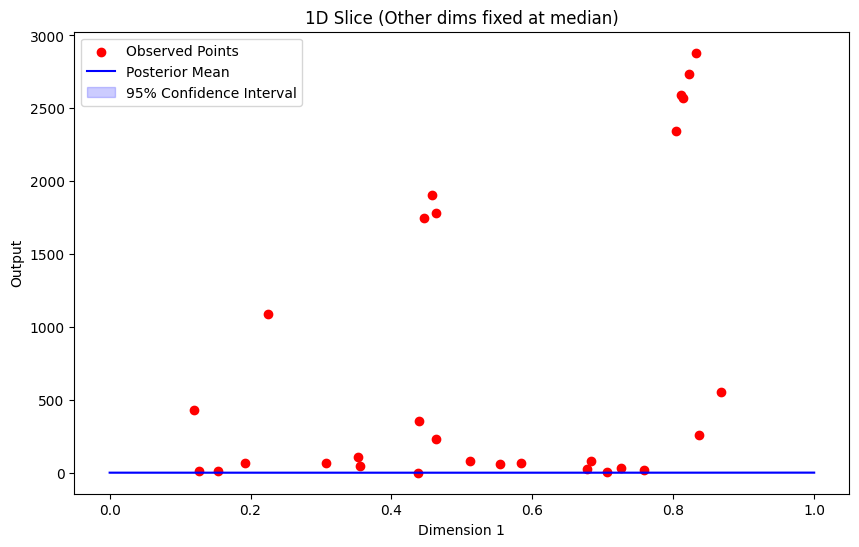

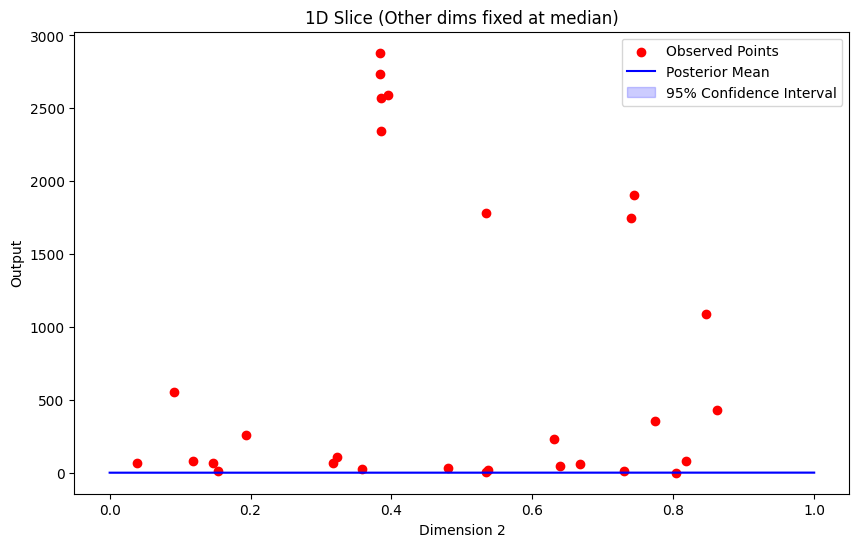

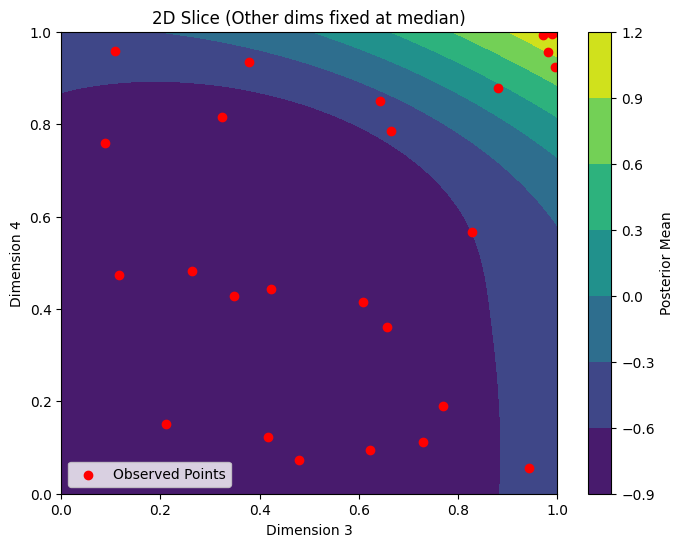

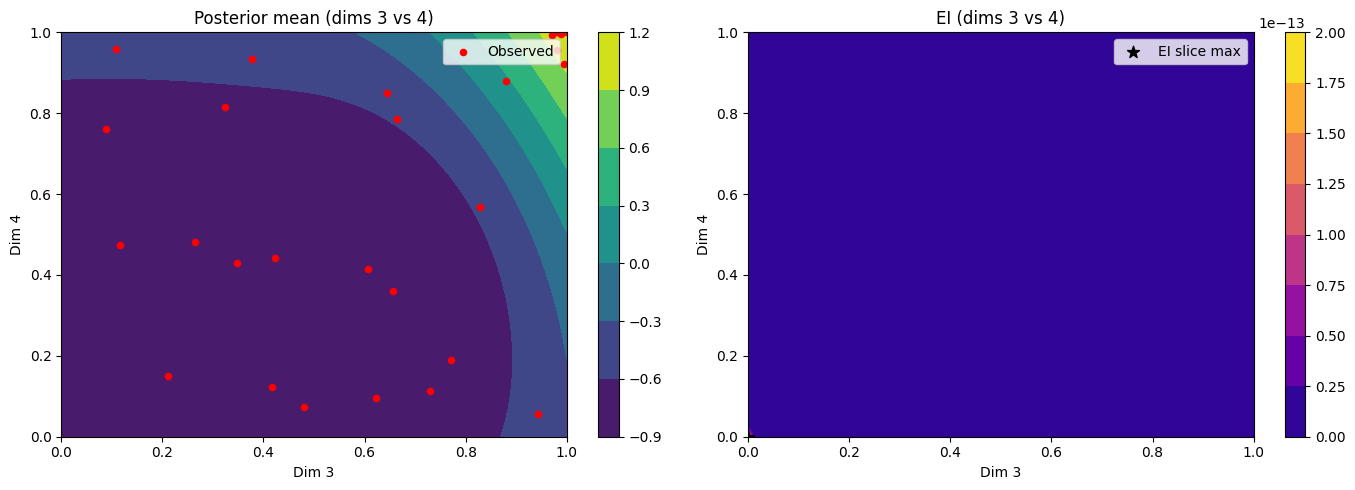

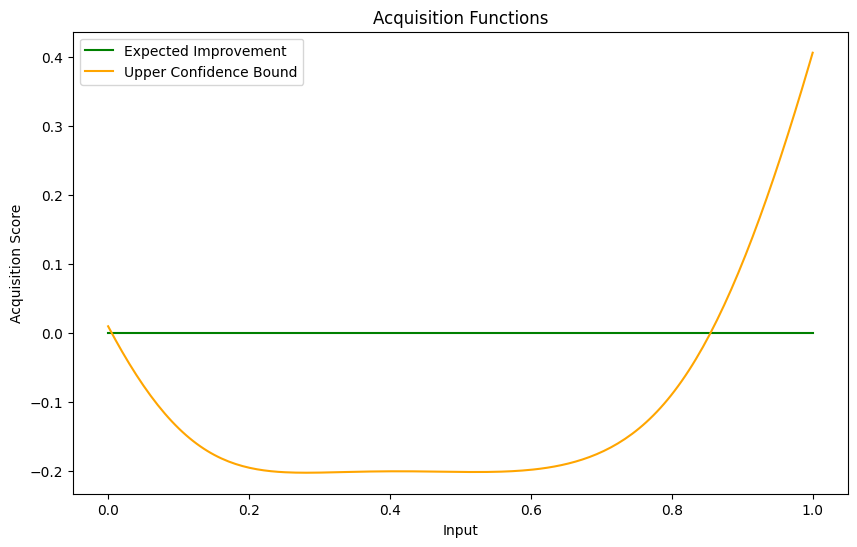

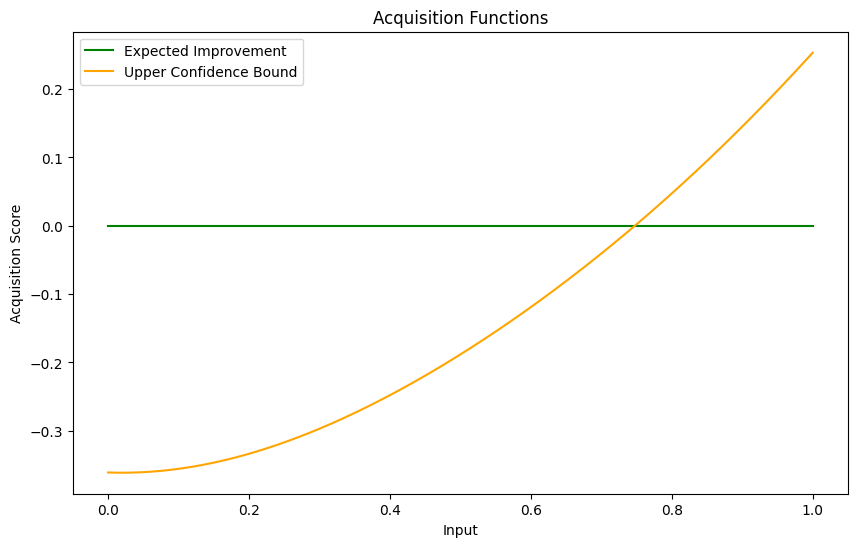

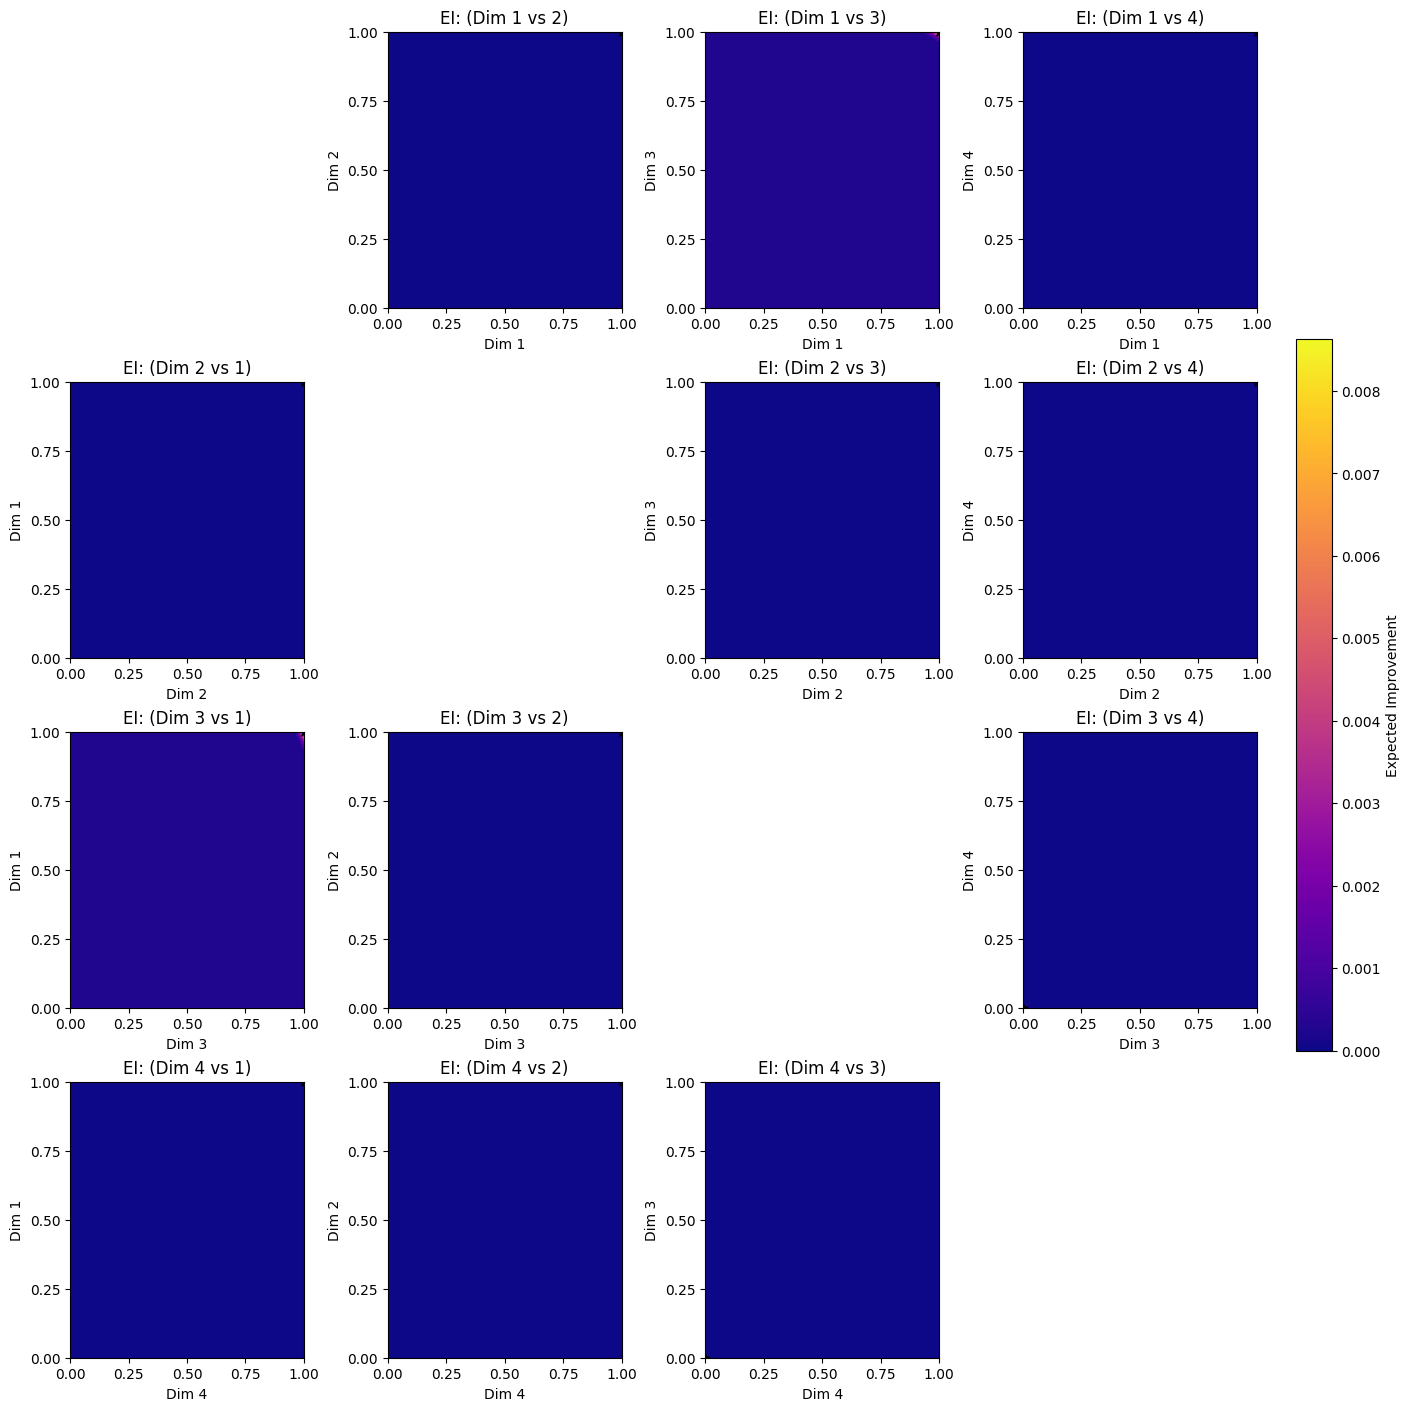

In [47]:
# Visualize slices of the surrogate model
D = X.shape[1]
# 1D slice for dimension 1
plot_gp_slice(X, Y, surrogate, cfg, pca, dims_to_vary=[0])

if D >= 2:
    plot_gp_slice(X, Y, surrogate, cfg, pca, dims_to_vary=[1])
    # auto‑pick one 2D pair: the two dims with highest variance
    variances = np.var(X, axis=0)
    top2 = np.argsort(variances)[-2:]


# 2D slice for dimensions 1 and 2
plot_gp_slice(X, Y, surrogate, cfg, pca, dims_to_vary=[int(top2[0]), int(top2[1])])
plot_2d_ei_slice(X, Y, surrogate, cfg, pca, d1=int(top2[0]), d2=int(top2[1]), n_points=100, Y_best=float(np.max(getattr(surrogate, "y_train_", Y))))


# Visualize acquisition functions for dimension 1 slice
# For high dimensions, we show EI and UCB along the varied dimension
grid_dim1 = np.linspace(0, 1, 200)
X_full_dim1 = np.tile(np.median(X, axis=0), (200, 1))
X_full_dim1[:, 0] = grid_dim1

X_grid_work = pca_transform_candidates(pca, X_full_dim1) if getattr(cfg, "use_pca", False) and pca is not None else X_full_dim1

ei_dim1  = expected_improvement(X_grid_work, surrogate, Y_best=float(np.max(getattr(surrogate, "y_train_", Y))))
ucb_dim1 = upper_confidence_bound(X_grid_work, surrogate, kappa=cfg.kappa)
plot_acquisition_functions(grid_dim1, ei_dim1, ucb_dim1)


# Visualize acquisition functions for dimension 2 slice
if D >= 2:
    grid_dim2 = np.linspace(0, 1, 200)
    X_full_dim2 = np.tile(np.median(X, axis=0), (200, 1))
    X_full_dim2[:, 1] = grid_dim2
    X_grid_work2 = pca_transform_candidates(pca, X_full_dim2) if getattr(cfg, "use_pca", False) and pca is not None else X_full_dim2
    
    ei_dim2  = expected_improvement(X_grid_work2, surrogate, Y_best=float(np.max(getattr(surrogate, "y_train_", Y))))
    ucb_dim2 = upper_confidence_bound(X_grid_work2, surrogate, kappa=cfg.kappa)
    plot_acquisition_functions(grid_dim2, ei_dim2, ucb_dim2)

# Pairplot of EI
pairplot_ei(X, Y, surrogate, n_dims=4, n_points=60, cmap="plasma")





Week 5 Strategy Visualisations

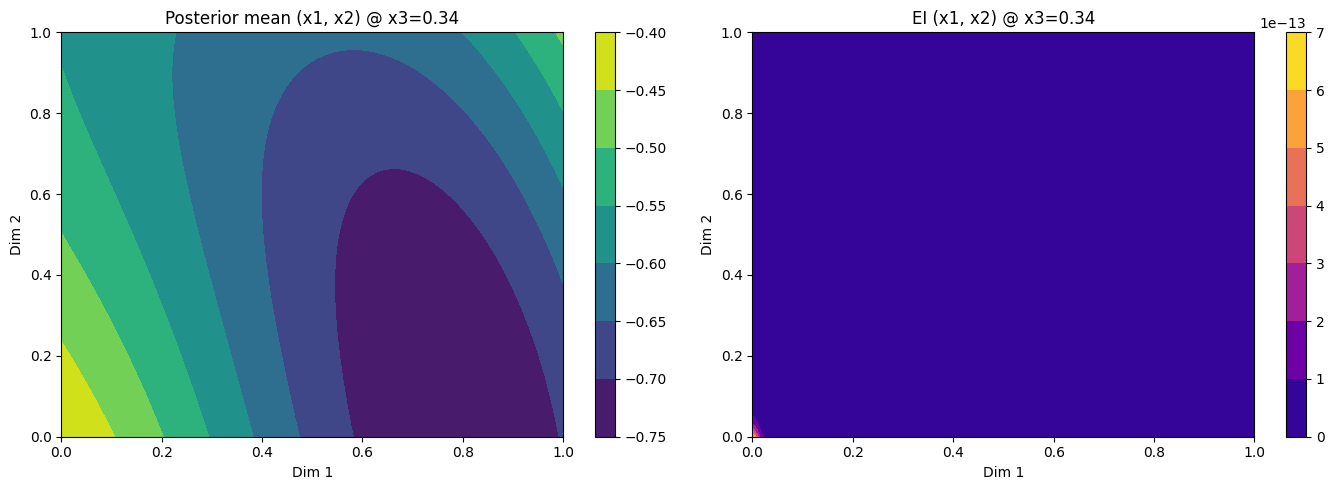

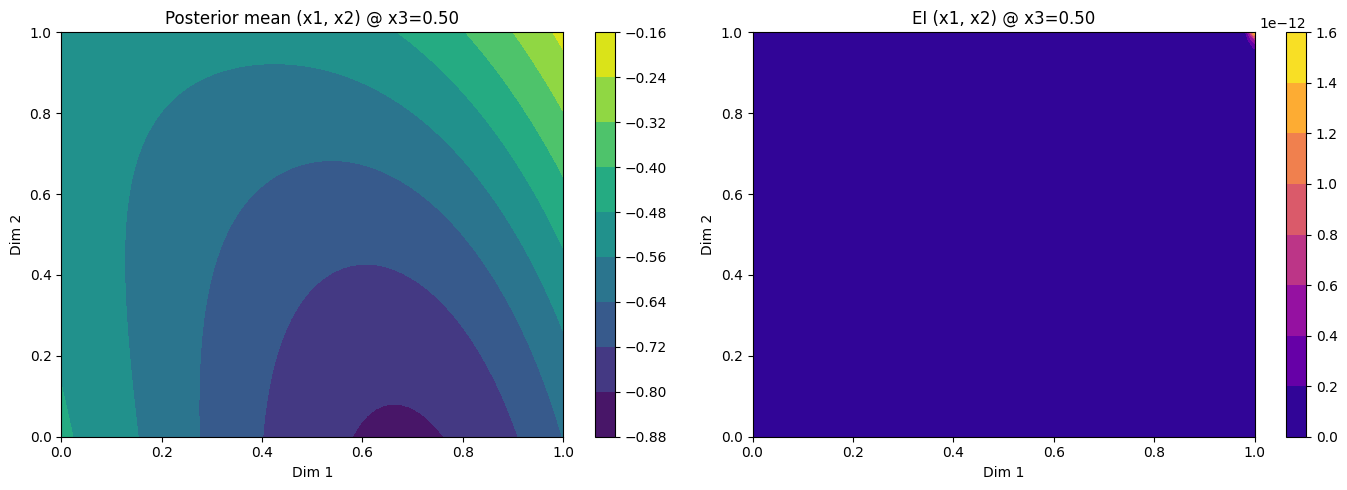

In [48]:

# Example for Function 5 (ridge scan over x1, x2; fix x3 at two levels)
plot_ridge_scan(X, Y, surrogate, cfg, pca, dim_pair=(0, 1), fixed_dim=2, fixed_values=[0.34, 0.50])


In [49]:
# Example for Function 6 (Exploration should be re‑centred on x1 and x2)
#plot_ridge_scan(X, Y, surrogate, cfg, pca, dim_pair=(0, 1),fixed_dim=2,fixed_values=[0.78, 0.88])


In [50]:
# Example for Function  (Exploration should be re‑centred on x4 and x5)
#plot_ridge_scan(X, Y, surrogate, cfg, pca,dim_pair=(0, 1), fixed_dim=3,fixed_values=[0.72, 0.90])


In [51]:
# Example for Function 7 (ridge scan over x5, x6 at low and mid x3)
#plot_ridge_scan(X, Y, surrogate, cfg, pca, dim_pair=(4, 5), fixed_dim=2, fixed_values=[0.34, 0.50])

In [52]:

# Example for Function 8 (ridge scan over x5, x6 at low and mid x3)
#plot_ridge_scan(X, Y, surrogate, cfg, pca, dim_pair=(4, 5), fixed_dim=2, fixed_values=[0.05, 0.15])



### Generate Next Queries
Call propose_next_queries(...) and capture numeric + formatted outputs.

In [53]:


# --- Hyperparameter BO: build/extend dataset, fit surrogate, propose next HPS ---
fast_hp = True  # Fast path toggle (set False for full HP tuning)
hp_bo_skipped = False  # NEW: guard flag

if getattr(cfg, "use_nn", False):
    # Try to resume from a previous best hyperparameter checkpoint
    hp_ckpt = load_hp_checkpoint(function_path)
    if hp_ckpt is not None:
        hp_best = hp_ckpt.get("best_hp_decoded", {})
        if hp_best:
            cfg.nn_hidden_layers = list(hp_best.get("hidden_layers", cfg.nn_hidden_layers))
            cfg.nn_learning_rate = float(hp_best.get("learning_rate", cfg.nn_learning_rate))
            cfg.nn_weight_decay  = float(hp_best.get("weight_decay", cfg.nn_weight_decay))
            print(f"[HP-BO] Loaded checkpoint "
                  f"(score={hp_ckpt.get('best_score', 'n/a')}, "
                  f"layers={cfg.nn_hidden_layers}, lr={cfg.nn_learning_rate}, wd={cfg.nn_weight_decay})")

            # --- Fast path skip (no return at top level) ---
            if fast_hp:
                print("[HP-BO] Fast path enabled: skipping HP tuning and refitting surrogate with checkpointed HPs.")
                X_work = pca_transform_candidates(pca, X) if (cfg.use_pca and pca is not None) else X
                surrogate = fit_nn(X_work, Y, cfg)
                hp_bo_skipped = True  # mark as handled

    # Only run the rest if we didn't skip
    if not hp_bo_skipped:
        # 3.1 Initialise or load HP dataset
        try:
            hp_X = np.load(f'{function_path}/hp_inputs.npy')   # <-- keep your correct path var (function_path)
            hp_Y = np.load(f'{function_path}/hp_outputs.npy')
        except Exception:
            hp_X = np.empty((0, 4), dtype=float)
            hp_Y = np.empty((0,), dtype=float)

        # 3.2 If dataset small, seed with LHS
        if len(hp_X) < 8:
            rng = np.random.default_rng(cfg.random_state)
            X_seed = _lhs(n=8, d=4, rng=rng)
            scores = []
            for x_hp in X_seed:
                if fast_hp:
                    s = evaluate_hp_candidate_fast(x_hp, X, Y, cfg, pca=pca)
                else:
                    s = evaluate_hp_candidate(x_hp, X, Y, cfg, rng=rng, pca=pca)
                scores.append(s)
            hp_X = np.vstack([hp_X, X_seed])
            hp_Y = np.append(hp_Y, np.array(scores, float))

        # 3.3 Fit a GP surrogate on HP data
        gp_hp = fit_gp(hp_X, hp_Y, cfg)

        # 3.4 Propose next hyperparameters
        hp_numeric, hp_formatted = propose_next_queries(hp_X, hp_Y, gp_hp, cfg, k_final=5)

        # 3.5 Evaluate proposed HPs, append to dataset, and persist
        hp_scores = []
        for x_hp in hp_numeric:
            if fast_hp:
                s = evaluate_hp_candidate_fast(x_hp, X, Y, cfg, pca=pca)
            else:
                s = evaluate_hp_candidate(x_hp, X, Y, cfg, pca=pca)
            hp_scores.append(s)

        hp_X = np.vstack([hp_X, np.array(hp_numeric)])
        hp_Y = np.append(hp_Y, np.array(hp_scores, float))

        np.save(f'{function_path}/hp_inputs.npy',  hp_X)
        np.save(f'{function_path}/hp_outputs.npy', hp_Y)

        # 3.6 Pick the best HP so far and set cfg accordingly
        best_idx = int(np.argmax(hp_Y))
        best_hp_decoded = _hp_decode(hp_X[best_idx])
        cfg.nn_hidden_layers = list(best_hp_decoded["hidden_layers"])
        cfg.nn_learning_rate = float(best_hp_decoded["learning_rate"])
        cfg.nn_weight_decay  = float(best_hp_decoded["weight_decay"])
        cfg.use_nn = True

        save_hp_checkpoint(function_path,
                           best_hp_decoded=best_hp_decoded,
                           best_score=float(hp_Y[best_idx]),
                           hp_X=hp_X, hp_Y=hp_Y, cfg=cfg)
        print("[HP-BO] Checkpoint saved.")
        print("[HP-BO] Best score:", float(hp_Y[best_idx]))
        print("[HP-BO] Best decoded HP:", best_hp_decoded)

        # Refit NN with tuned hyperparameters (once)
        surrogate = fit_nn(X if not (cfg.use_pca and pca is not None) else X_work, Y, cfg)

else:
    print("[HP-BO] Skipped (cfg.use_nn=False). Using GP surrogate with current configuration.")
    # surrogate already defined upstream in your notebook


[HP-BO] Skipped (cfg.use_nn=False). Using GP surrogate with current configuration.


### Reporting
Print current best observation and proposed queries.

[function_5] kappa=2.5, xi=0.01, n_global_factor=3000, trust_radius_base=0.005, use_svm=False, use_feature_screen=False, use_pca=False, use_perturbations=True, perturb_rate_base=0.04
Top-K diversity: insufficient points to assess spread.
Top-k candidate means: {'x1': np.float32(0.965), 'x2': np.float32(0.739), 'x3': np.float32(0.977), 'x4': np.float32(0.932)}
Top-k candidate stds : {'x1': np.float32(0.043), 'x2': np.float32(0.144), 'x3': np.float32(0.016), 'x4': np.float32(0.053)}


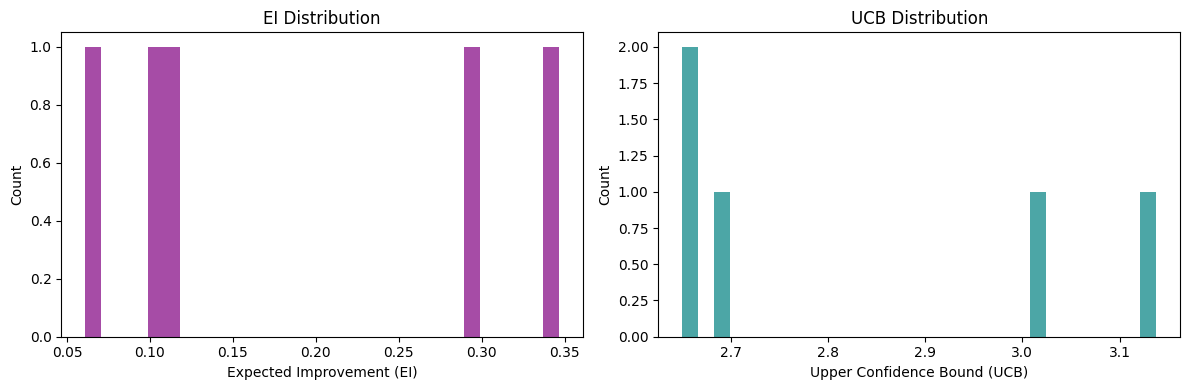


[ARD] Sensitivities (abs) by dimension (desc):
   1. dim 3: sens=1.1337, rel=1.000, keep=True
   2. dim 1: sens=0.6756, rel=0.596, keep=True
   3. dim 4: sens=0.6234, rel=0.550, keep=True
   4. dim 2: sens=0.2967, rel=0.262, keep=True

[Diversity] per-dim std: [0.043 0.144 0.016 0.053]
[Diversity] mean pairwise distance: 0.2308


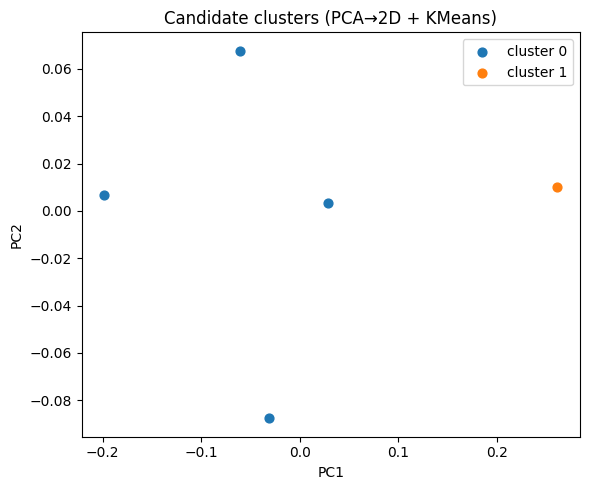

[function_5] Week-5 update:
  D=4, kappa=2.500, xi=0.010, n_global_factor=3000, trust_radius_base=0.0050
[function_5] shapes - X: (29, 4), Y: (29,)
[function_5] Current best Y: 2881.360383 @ idx 27
X_best: [0.832212, 0.383312, 0.999999, 0.999999]
  Surrogate used for proposals: Gaussian Process

[function_5] Proposed next queries (top 5):
 1. 0.881113-0.982058-0.996190-0.981292
 2. 0.982184-0.770928-0.983099-0.948462
 3. 0.968623-0.667858-0.949737-0.985291
 4. 0.994407-0.544081-0.988419-0.899385
 5. 0.997564-0.731511-0.969924-0.844591
[Portal] function_5 top-1: 0.881113-0.982058-0.996190-0.981292


In [54]:
# === Main Workflow (Unified Week-5; GP/NN/PCA-aware) ===
# 1) Dynamic κ/ξ adjustment per Week-5 strategy
cfg = schedule_acquisition(cfg, bool(getattr(cfg, "improved_last_round", True)))

# prove nothing re-overrides these
print(f"[{function_name}] kappa={cfg.kappa}, xi={cfg.xi}, n_global_factor={cfg.n_global_factor}, "
      f"trust_radius_base={cfg.trust_radius_base}, use_svm={cfg.use_svm}, "
      f"use_feature_screen={cfg.use_feature_screen}, use_pca={cfg.use_pca}, "
      f"use_perturbations={cfg.use_perturbations}, perturb_rate_base={cfg.perturb_rate_base}")

# 2) Propose next queries (single call; all Week-5 guarantees are inside)
numeric, formatted = propose_next_queries(X, Y, surrogate, cfg, k_final=5, pca=pca)

# 3) Diagnostics (top-k cluster stats) — optional but helpful
try:
    log_topk_cluster_stats(np.array(numeric))
except Exception:
    pass

# NEW: rich diagnostics
diagnostics_after_proposal(X, Y, surrogate, cfg, numeric, pca=pca, k_final=5)
    

# 4) Reporting (consistent style)
function_name = locals().get("function_name", "function")
D = int(X.shape[1])
print(f"[{function_name}] Week-5 update:")
print(f"  D={D}, kappa={cfg.kappa:.3f}, xi={cfg.xi:.3f}, n_global_factor={cfg.n_global_factor}, trust_radius_base={cfg.trust_radius_base:.4f}")

# Console report with surrogate info
print(f"[{function_name}] shapes - X: {X.shape}, Y: {Y.shape}")
idx_best = int(np.argmax(Y))
print(f"[{function_name}] Current best Y: {float(Y[idx_best]):.6f} @ idx {idx_best}")
print("X_best:", np.array2string(X[idx_best], precision=6, separator=', '))

surrogate_type = "Neural Network" if getattr(cfg, "use_nn", False) else "Gaussian Process"
print(f"  Surrogate used for proposals: {surrogate_type}")
if getattr(cfg, "use_nn", False):
    print("  NN Hyperparameters:")
    print(f"    Hidden layers: {getattr(cfg, 'nn_hidden_layers', [])}")
    print(f"    Learning rate: {getattr(cfg, 'nn_learning_rate', 'n/a')}")
    print(f"    Weight decay:  {getattr(cfg, 'nn_weight_decay', 'n/a')}")

if formatted and len(formatted) > 0:
    print(f"\n[{function_name}] Proposed next queries (top {len(formatted)}):")
    for i, fq in enumerate(formatted, 1):
        print(f" {i}. {fq}")
    print(f"[Portal] {function_name} top-1: {formatted[0]}")
else:
    print(f"\n[{function_name}] No candidates returned. Consider increasing cfg.n_global_factor or lowering cfg.svm_keep_frac.")




## FUNCTION 5 (Super‑Exploit the 2733 Peak)

FINAL FUNCTION 5 SUBMISSION: 0.810389-0.395809-0.988672-0.995824


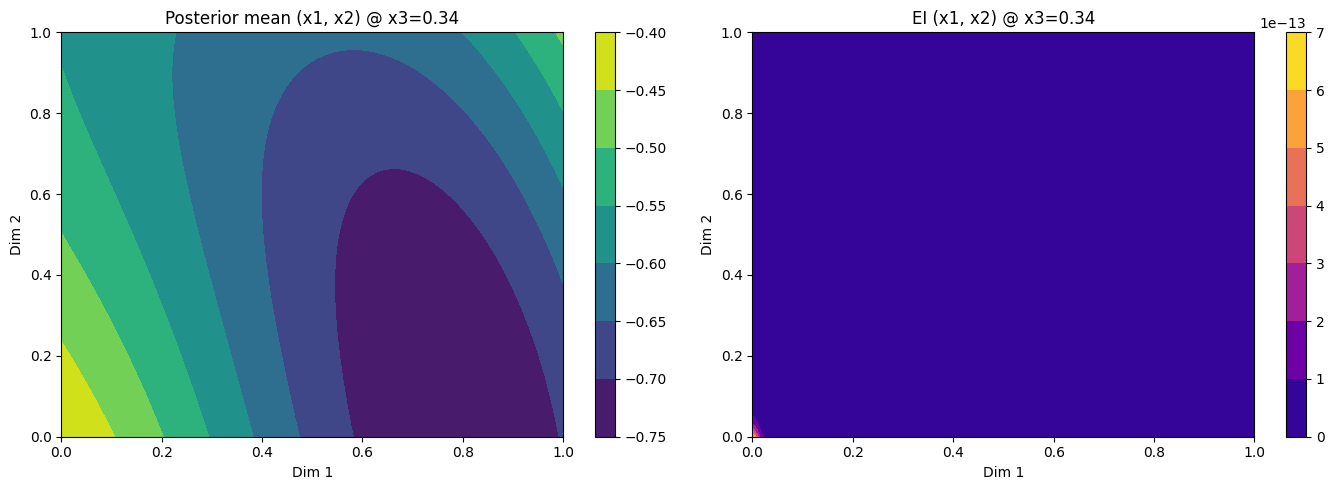

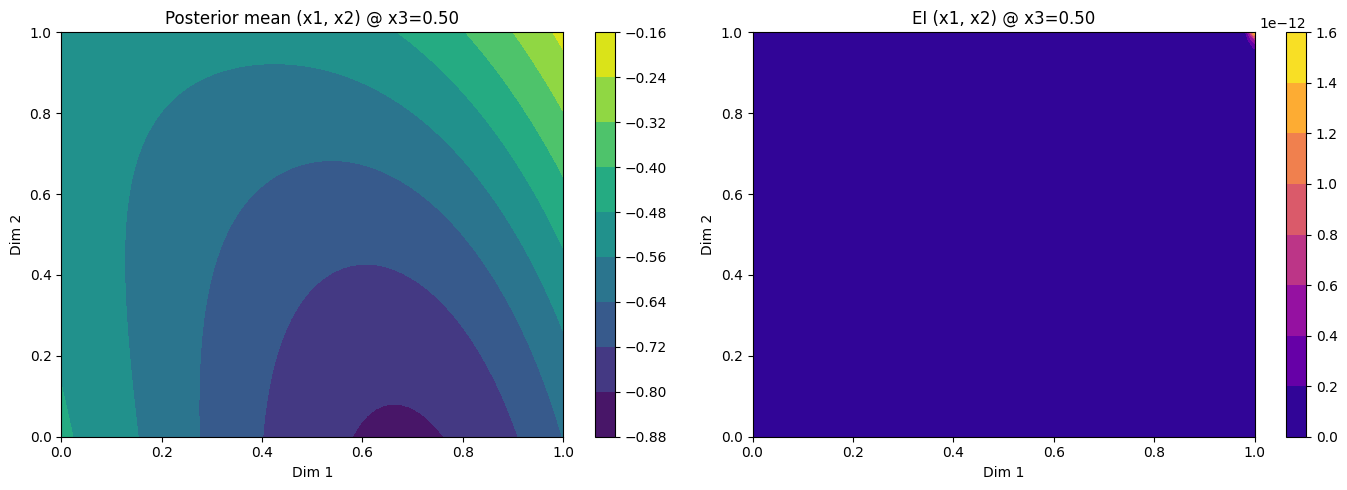

In [27]:
# ================================================================
# FINAL CORRECTED FUNCTION 5 – TRUE RIDGE CENTRE EXPLOIT
# ================================================================

import numpy as np

# Define final trust-region corrected config if missing
try:
    cfg_F5_final
except NameError:
    cfg_F5_final = BOConfig(
        xi = 0.01,           # minimal exploration
        kappa = 2.5,          # prevent drift into uncertainty pockets
        use_svm = False,
        svm_high_quantile = 0.65,
        svm_keep_frac = 0.60,
        use_feature_screen = False,
        ard_rel_threshold = 0.20,
        use_perturbations = True,
        perturb_rate_base = 0.04,
        batch_predict_size = 10000,
        standardize_y = True,
        use_pca = False,
        pca_var_keep = 0.95,
        use_nn = False,
        nn_hidden_layers=[128,128],
        nn_learning_rate=1e-3,
        nn_weight_decay=1e-4,
        nn_epochs=150,
        nn_ensemble=4,
        n_global_factor=3000,
        trust_radius_base=0.005,
        improved_last_round=True,
        standardize_y = True
    )

# True ridge window based on your results
def ridge_center_candidates(n=80, seed=42):
    rng = np.random.default_rng(seed)
    X = np.zeros((n,4))

    X[:,0] = rng.uniform(0.82, 0.87, n)       # x1 safe peak zone
    X[:,1] = rng.uniform(0.35, 0.43, n)       # x2 corrected downward
    X[:,2] = rng.uniform(0.997,1.000, n)      # x3 locked high
    X[:,3] = rng.uniform(0.997,1.000, n)      # x4 locked high

    return np.clip(X, 0, 0.999999)

Xcand = ridge_center_candidates(80)

# Micro-perturb Week 7 peak
anchor = np.array([0.822687, 0.384018, 0.991877, 0.999999])
rng = np.random.default_rng(99)
X_micro = anchor + rng.normal(0, 0.007, size=(40,4))
X_micro = np.clip(X_micro, 0, 0.999999)

# Combine
Xcand = np.unique(np.vstack([Xcand, X_micro]), axis=0)

# Train SVM and gate
svm = train_svm_classifier(X, Y, cfg_F5_final)
svm_scores = svm.decision_function(Xcand)
keep_idx = svm_gate_fast(svm_scores, keep_frac=cfg_F5_final.svm_keep_frac)
Xcand = Xcand[keep_idx] if keep_idx.size > 0 else Xcand

# Score EI+UCB
ei, ucb, mu, std = acquisition_scores_single_pass(
    surrogate, Xcand, Y.max(),
    xi=cfg_F5_final.xi, 
    kappa=cfg_F5_final.kappa
)

# Select best EI
x_final = Xcand[np.argmax(ei)]
x_final = np.clip(x_final, 0, 0.999999)

portal = "-".join([f"{v:.6f}" for v in x_final])
print("FINAL FUNCTION 5 SUBMISSION:", portal)

# Ridge visualisation
try:
    plot_ridge_scan(
        X, Y, surrogate, cfg_F5_final, pca,
        dim_pair=(0,1), fixed_dim=2,
        fixed_values=[0.34, 0.50]
    )
except Exception as e:
    print("Ridge scan skipped:", e)